dataset

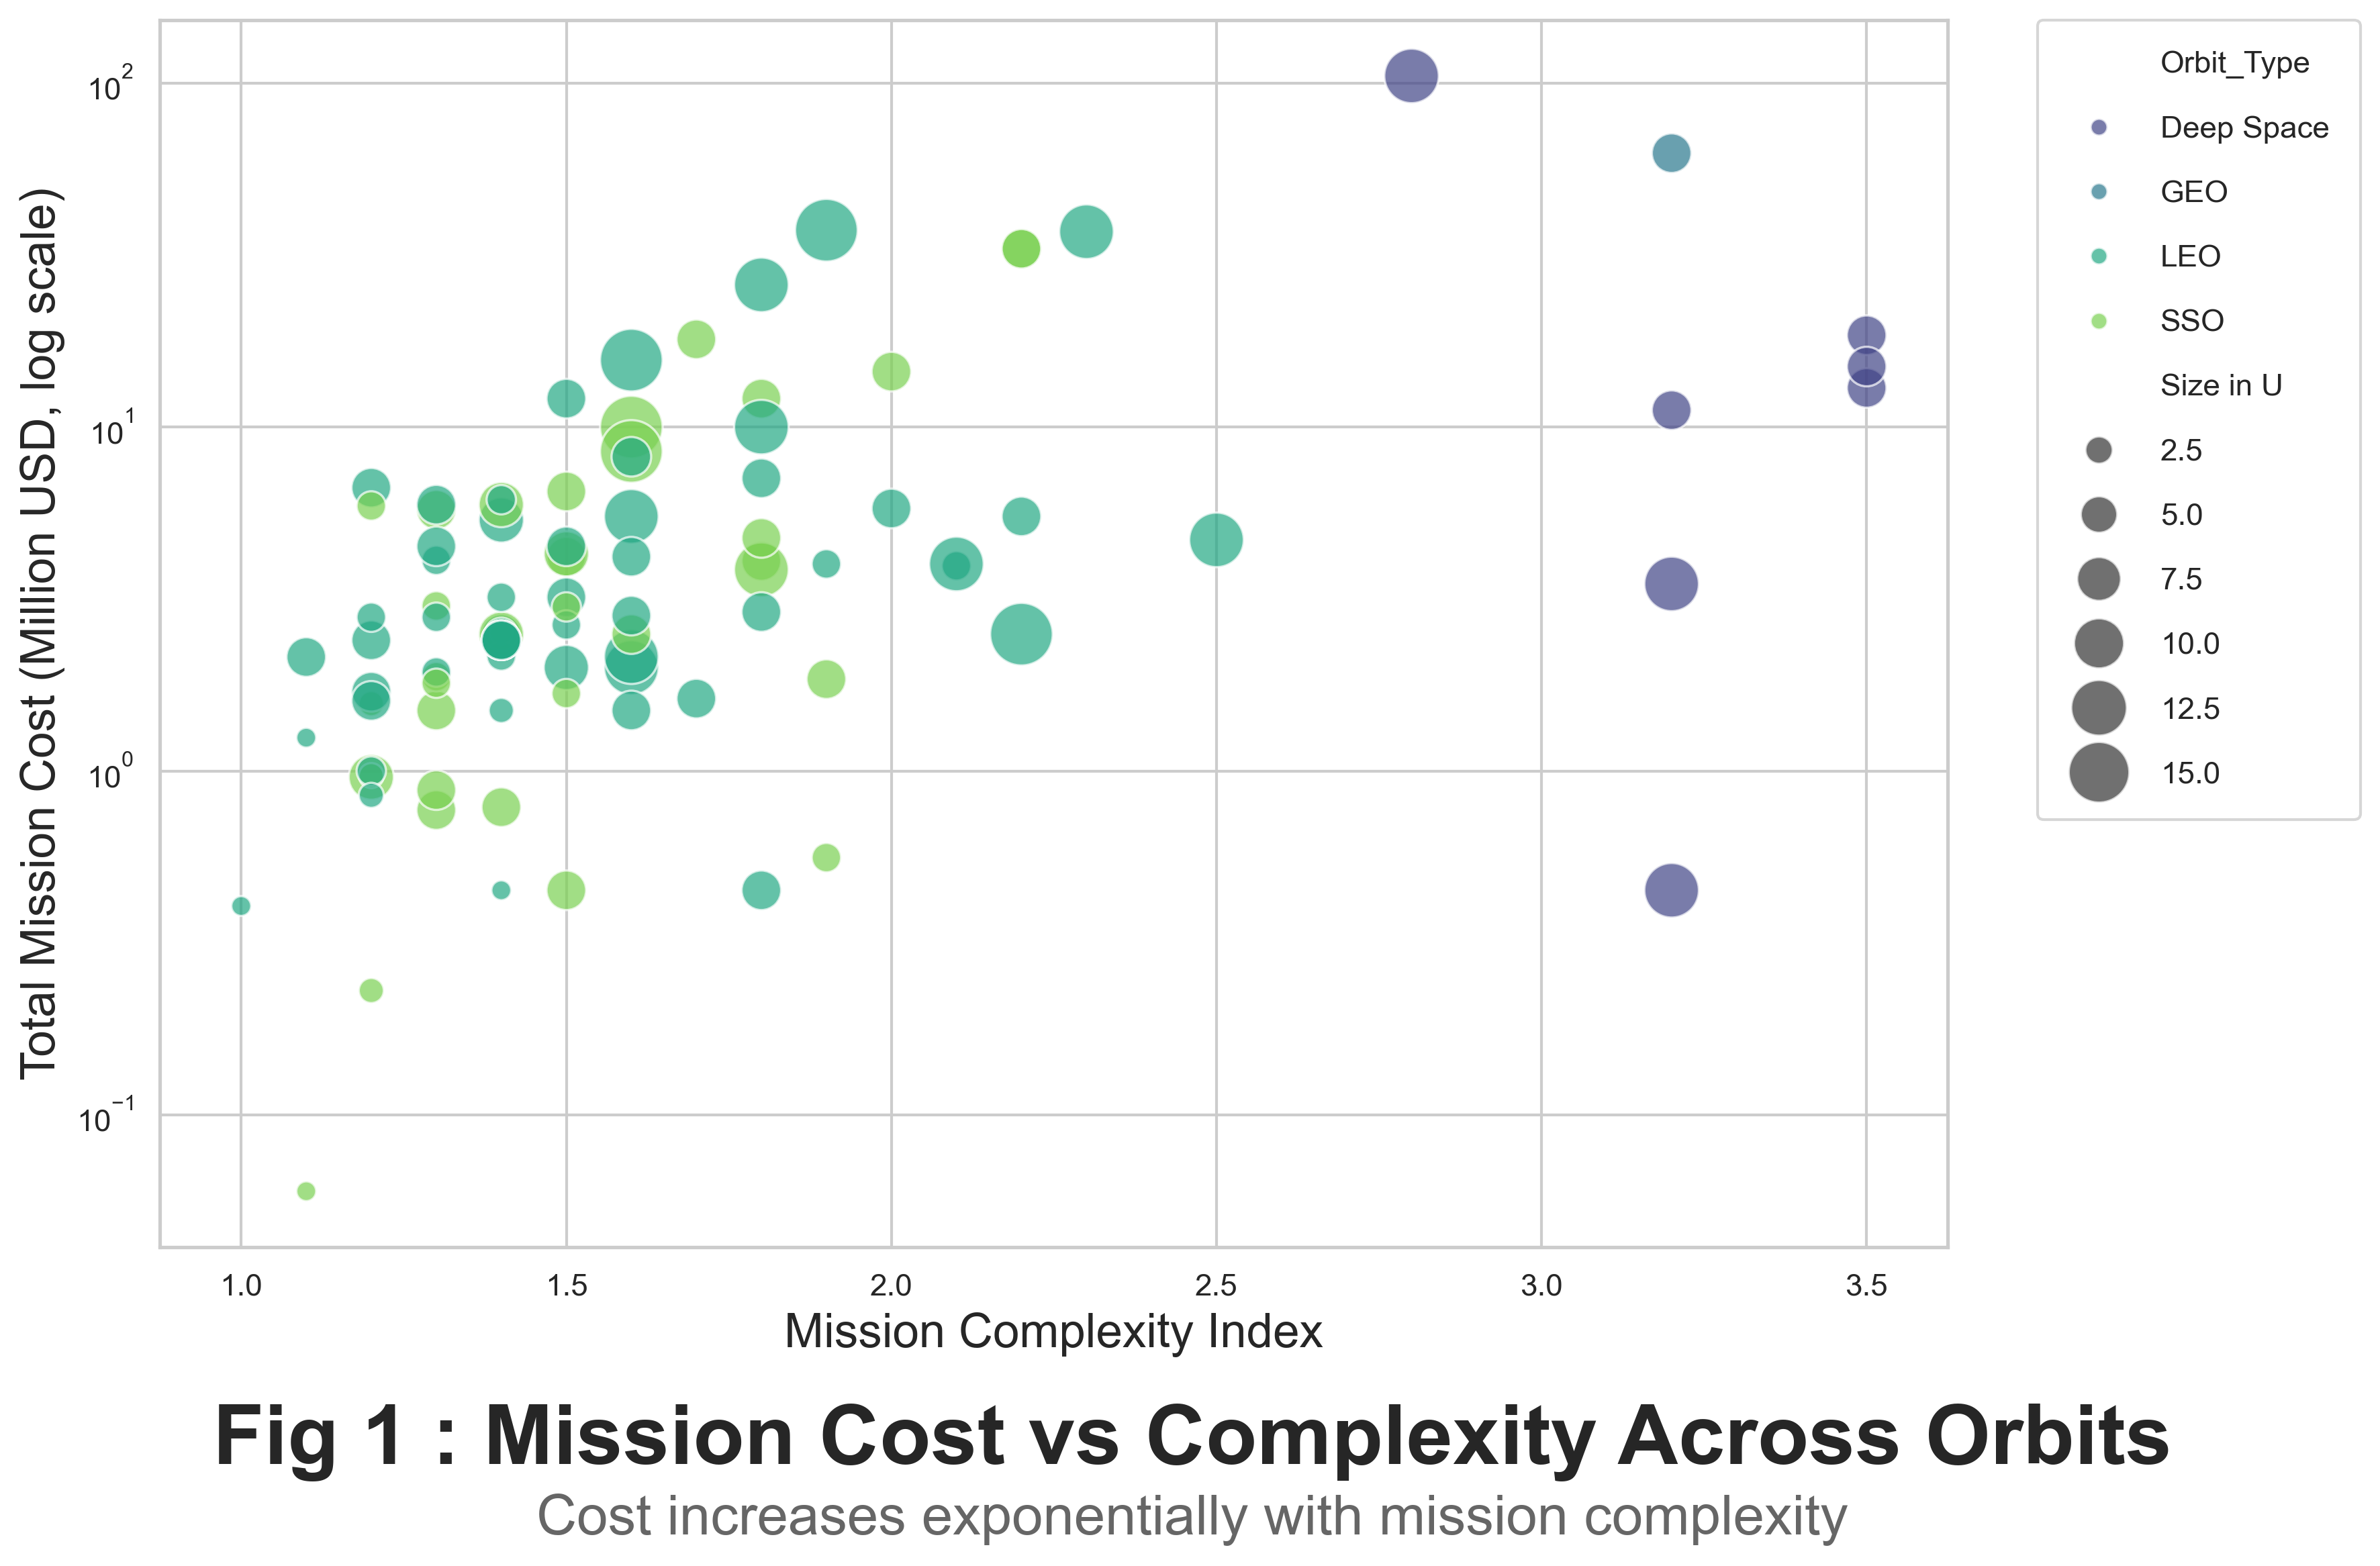

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION VISUELLE ---
# On choisit un style blanc et quadrillé, parfait pour l'impression sur poster
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 100 

# --- 2. CHARGEMENT ET NETTOYAGE ---
file_path = "ESA_CNES - CubeSeat Dataset - data.csv"
df = pd.read_csv(file_path)

#df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes

# Nettoyage de la colonne Coût : on remplace la virgule par un point et on convertit en float
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)

# --- 4. SCATTER PLOT (LE PLAN KNN) ---
plt.figure(figsize=(12, 7), dpi=300)
sns.scatterplot(
    data=df, 
    x='Complexity_Score', 
    y='Coût Total (USD)', 
    hue='Orbit_Type', 
    size='Size in U', 
    sizes=(50, 500), 
    alpha=0.7,
    palette="viridis"
)


plt.yscale('log') # Échelle log car les coûts varient de 0.06 à 105M$
plt.gcf().text(
    0.5, -0.05,  # position (x centré, y sous la figure)
    "Fig 1 : Mission Cost vs Complexity Across Orbits",
    ha='center',
    fontsize=30,
    fontweight='bold'
)

# Sous-titre (tu peux ajuster aussi)
plt.gcf().text(
    0.5, -0.10,
    "Cost increases exponentially with mission complexity",
    ha='center',
    fontsize=20,
    color='#666'
)
plt.xlabel("Mission Complexity Index", fontsize=17)
plt.ylabel("Total Mission Cost (Million USD, log scale)", fontsize=17)
plt.legend(bbox_to_anchor=(1.05, 1), 
            loc='upper left',
            borderaxespad=0.,
            labelspacing=1.2,
            handletextpad=1.0,
            borderpad=1.0
            )
plt.tight_layout()
plt.show()


Model

In [5]:
import pymc as pm
import numpy as np
import pandas as pd
import arviz as az

df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")

# On centre l'année pour aider le modèle à converger (2024 = 0)
df['Year_Scaled'] = df['Année (Launch)'] - 2024
# Avant de définir ton modèle, fusionne les catégories dans ton dataframe
df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')
df['Orbit_Type'] = df['Orbit_Type'].astype('category')
orbit_names = df['Orbit_Type'].cat.categories
df['orbit_idx'] = df['Orbit_Type'].cat.codes
# Suppression de la ligne vide si nécessaire
df = df.dropna(subset=['Coût Total (USD)'])

n_orbits = len(orbit_names)
# 2. Construction du Modèle Bayésien
with pm.Model() as cubesat_model:
    # --- Priors (nos hypothèses de départ) ---
    alpha_orbit = pm.Normal("alpha_orbit", mu=0, sigma=1.5, shape=n_orbits)
    beta_size = pm.Normal("beta_size", mu=0.5, sigma=1)
    beta_complexity = pm.Normal("beta_complexity", mu=1, sigma=1) # On s'attend à un effet fort
    beta_comm = pm.Normal("beta_comm", mu=0, sigma=1)
    beta_year = pm.Normal("beta_year", mu=0, sigma=1)
    
    sigma = pm.HalfNormal("sigma", sigma=1) # Incertitude du modèle
    
    # --- Équation de la moyenne (Log-Link) ---
    mu = (alpha_orbit[df.orbit_idx.values] + 
          beta_size * df['Size in U'].values + 
          beta_complexity * df['Complexity_Score'].values +
          beta_comm * df['Is_Commercial'].values + 
          beta_year * df['Year_Scaled'].values)
    
    # --- Likelihood (La loi Log-Normale) ---
    y_obs = pm.LogNormal("y_obs", mu=mu, sigma=sigma, observed=df['Coût Total (USD)'].values)
    
    # --- Inférence (Le modèle "apprend") ---
    trace = pm.sample(2000, tune=1000, target_accept=0.95)

# 3. Visualisation des résultats


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\threadpoolctl.py:1226: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (2 chains in 2 jobs)
NUTS: [alpha_orbit, beta_size, beta_complexity, beta_comm, beta_year, sigma]


c:\Users\BRAVO\.conda\envs\pymc_env\Lib\site-packages\rich\live.py:260: UserWarning: install "ipywidgets" for 
Jupyter support
  warnings.warn('install "ipywidgets" for Jupyter support')

Sampling 2 chains for 1_000 tune and 2_000 draw iterations (2_000 + 4_000 draws total) took 82 seconds.
We recommend running at least 4 chains for robust computation of convergence diagnostics


                  mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  ess_bulk  \
alpha_orbit[0]  -1.030  0.867  -2.665    0.586      0.021    0.014    1652.0   
alpha_orbit[1]  -0.589  0.445  -1.438    0.238      0.011    0.007    1569.0   
alpha_orbit[2]  -0.672  0.459  -1.588    0.156      0.012    0.007    1570.0   
beta_size        0.081  0.033   0.019    0.140      0.001    0.001    3250.0   
beta_complexity  0.913  0.277   0.388    1.424      0.007    0.004    1738.0   
beta_comm       -0.133  0.219  -0.540    0.280      0.004    0.004    3405.0   
beta_year        0.046  0.043  -0.035    0.127      0.001    0.001    3125.0   
sigma            1.022  0.075   0.894    1.164      0.001    0.002    3418.0   

                 ess_tail  r_hat  
alpha_orbit[0]     2375.0    1.0  
alpha_orbit[1]     2144.0    1.0  
alpha_orbit[2]     2209.0    1.0  
beta_size          2538.0    1.0  
beta_complexity    2287.0    1.0  
beta_comm          2327.0    1.0  
beta_year          2185.0    1.0  

<Figure size 1000x600 with 0 Axes>

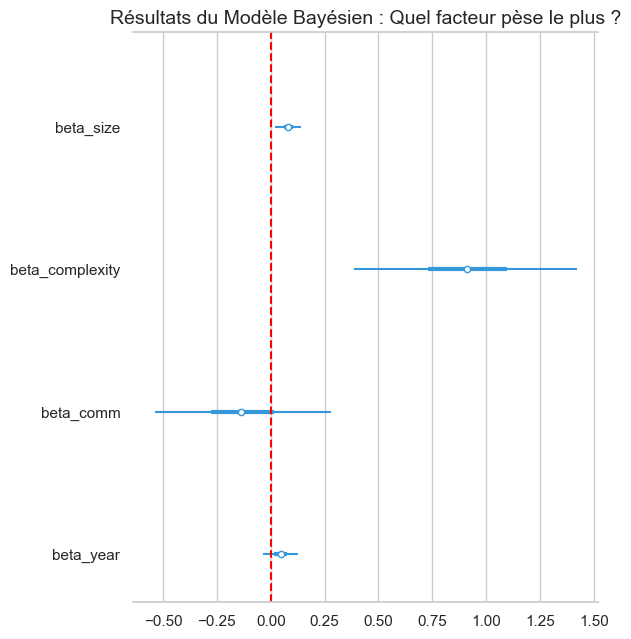

In [6]:
print(az.summary(trace))
plt.figure(figsize=(10, 6))
az.plot_forest(trace, var_names=["beta_size", "beta_complexity", "beta_comm", "beta_year"], combined=True, colors="#3498db")
plt.axvline(0, color='red', linestyle='--')
plt.title("Résultats du Modèle Bayésien : Quel facteur pèse le plus ?", fontsize=14)
plt.show()

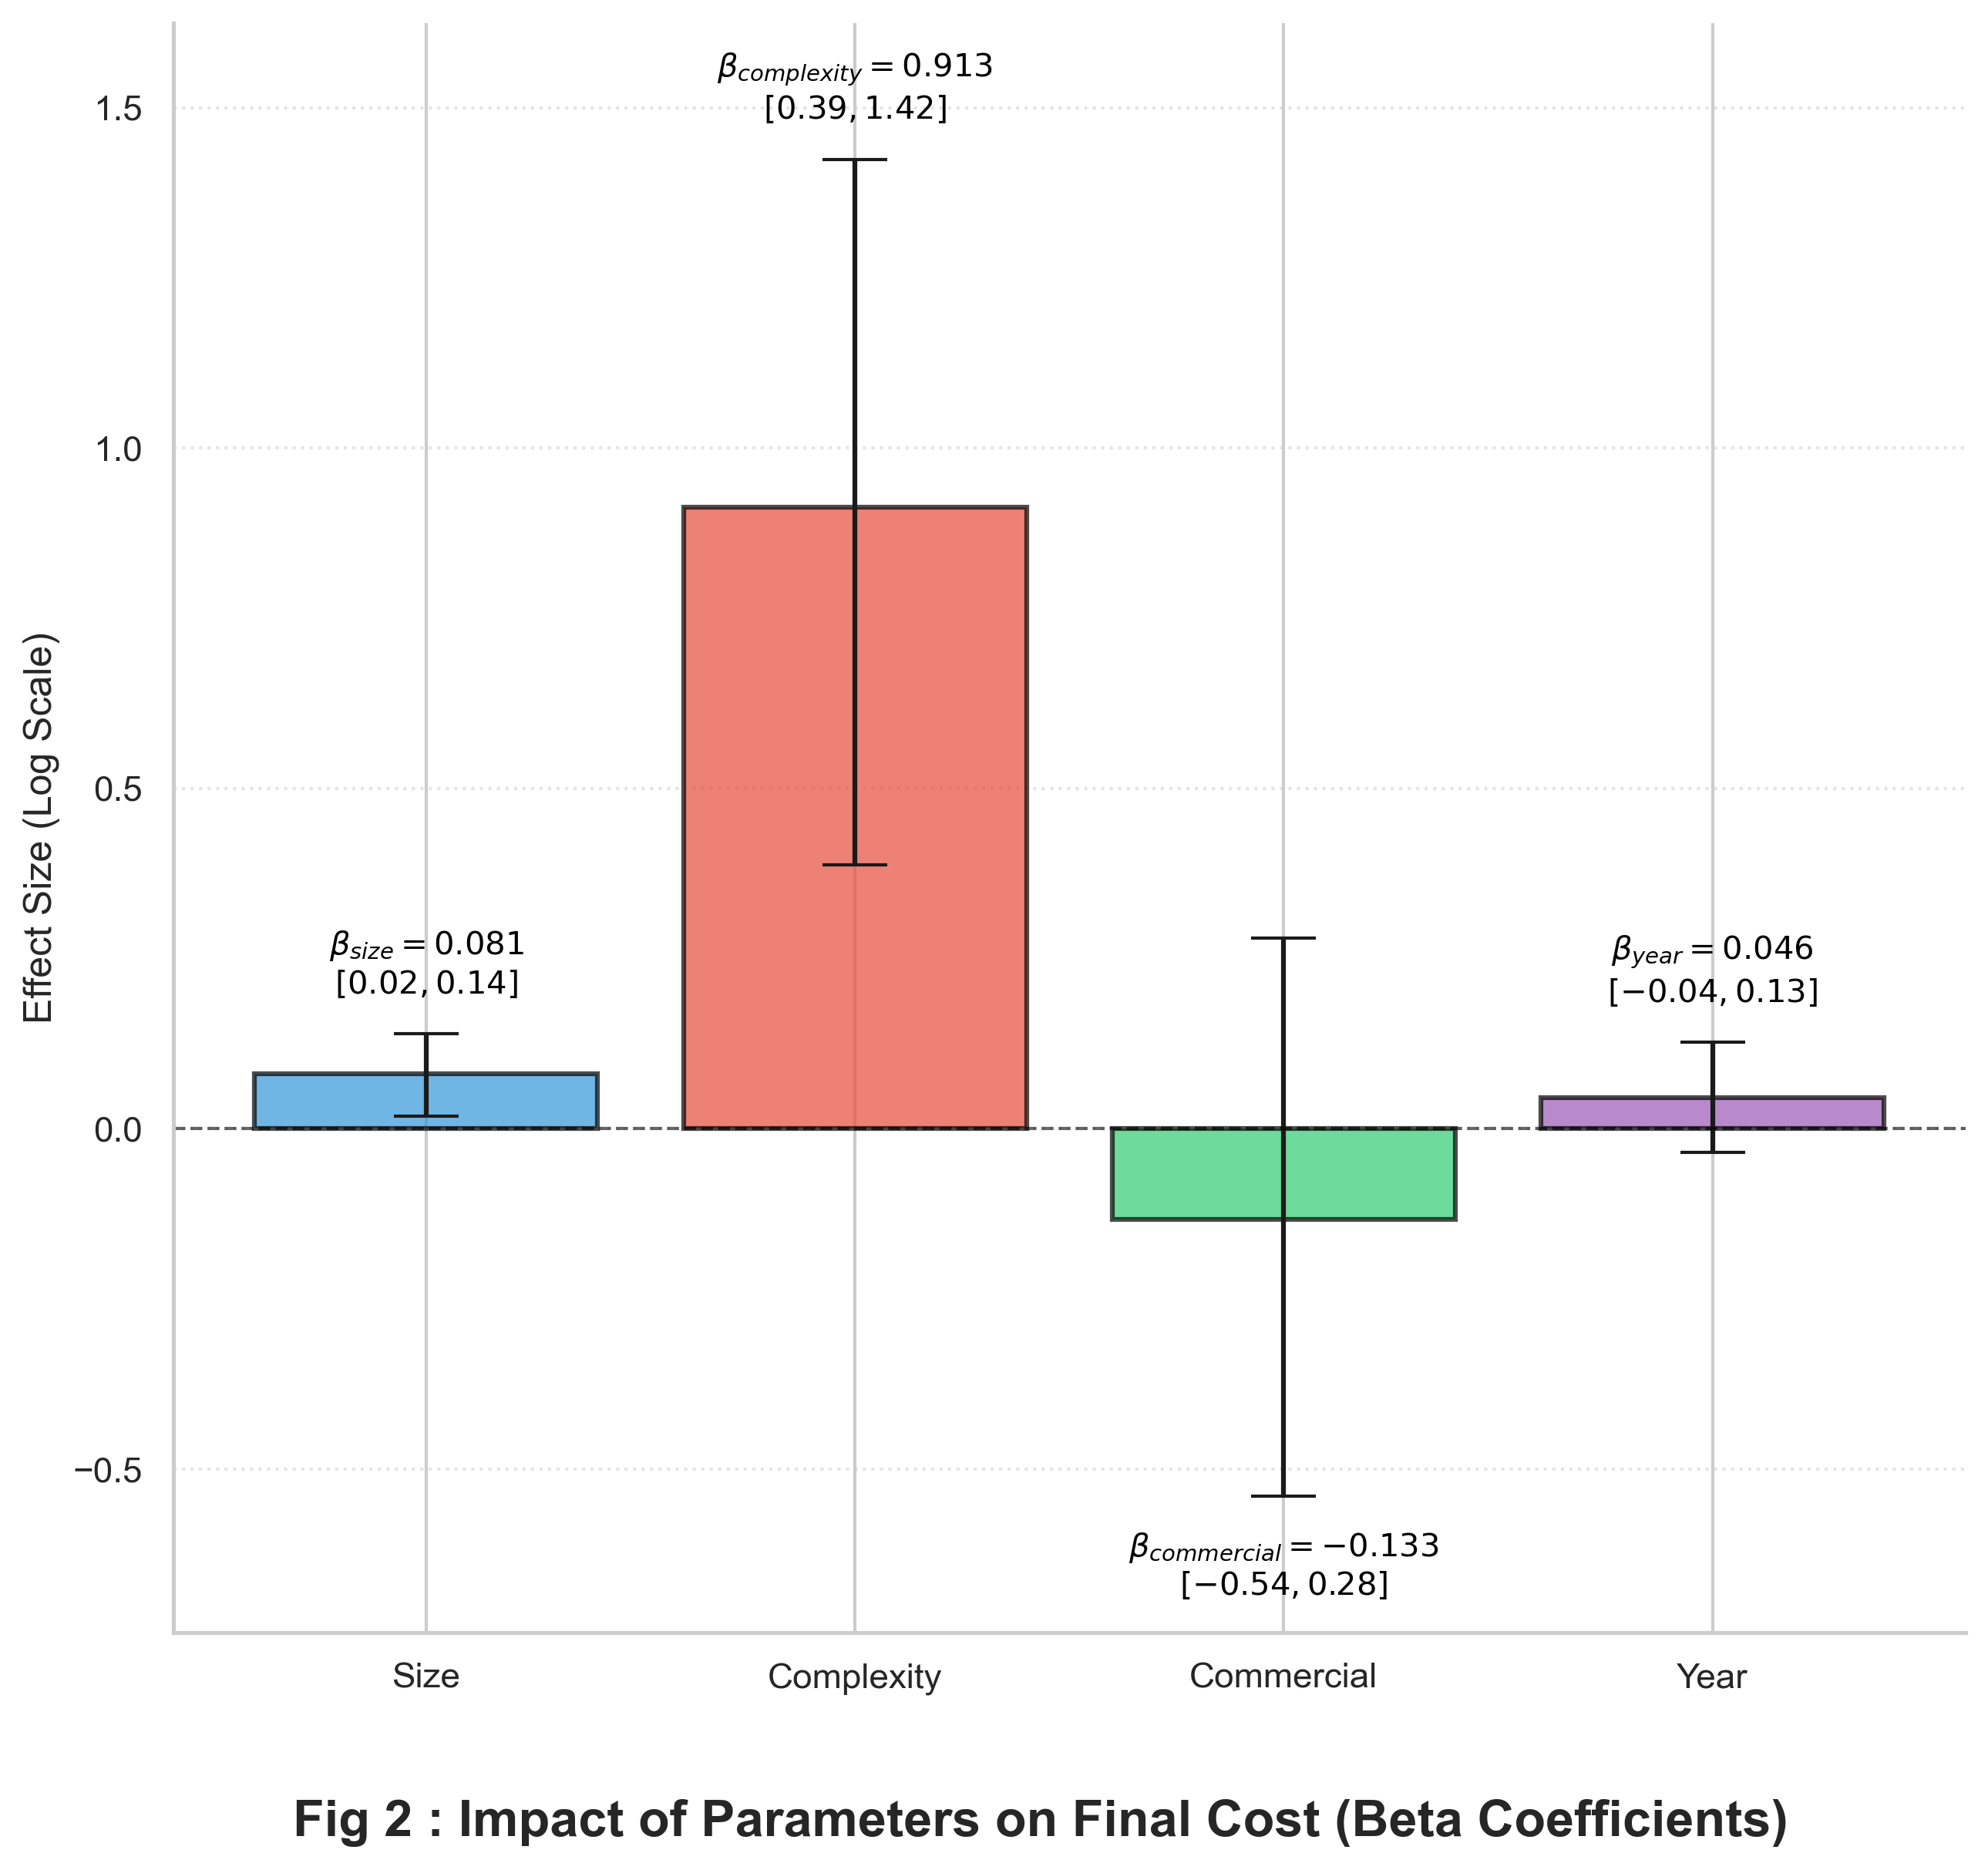

In [23]:
import matplotlib.pyplot as plt

# Données
labels = ["Size", "Complexity", "Commercial", "Year"]
means = [0.081, 0.913, -0.133, 0.046]
hdi_low = [0.019, 0.388, -0.540, -0.035]
hdi_high = [0.140, 1.424, 0.280, 0.127]

# Calcul des erreurs
yerr_down = [m - l for m, l in zip(means, hdi_low)]
yerr_up = [h - m for m, h in zip(means, hdi_high)]

fig, ax = plt.subplots(figsize=(10, 8), dpi=300)
colors = ['#3498db', '#e74c3c', '#2ecc71', '#9b59b6']

bars = ax.bar(labels, means, yerr=[yerr_down, yerr_up], 
              color=colors, alpha=0.7, capsize=10, 
              edgecolor='black', linewidth=1.5)

# --- SOLUTION POUR LES COLLISIONS ---
for i, bar in enumerate(bars):
    height = bar.get_height()
    
    # Texte du label avec moyenne et crochets HDI
    label_text = fr"$\beta_{{{labels[i].lower()}}} = {means[i]:.3f}$" + "\n" + fr"$[{hdi_low[i]:.2f}, {hdi_high[i]:.2f}]$"
    
    if height >= 0:
        # Pour les barres positives : au-dessus de la moustache haute
        y_pos = hdi_high[i] + 0.05
        va = 'bottom'
    else:
        # Pour les barres négatives : en-dessous de la moustache basse
        # On descend assez pour ne pas toucher le nom "Commercial"
        y_pos = hdi_low[i] - 0.05
        va = 'top'
    
    ax.text(bar.get_x() + bar.get_width()/2, y_pos, label_text, 
            ha='center', va=va, fontweight='bold', fontsize=10, color='black')

# Ligne de neutralité
ax.axhline(0, color='black', linestyle='--', linewidth=1, alpha=0.6)

# Ajustement des limites pour que le texte ne sorte pas du cadre
ax.set_ylim(min(hdi_low) - 0.2, max(hdi_high) + 0.2)

# Cosmétique
fig.text(
    0.5, -0.1,
    "Fig 2 : Impact of Parameters on Final Cost (Beta Coefficients)",
    ha='center',
    fontsize=16,
    fontweight='bold'
)
ax.set_ylabel("Effect Size (Log Scale)", fontsize=12)
ax.grid(axis='y', linestyle=':', alpha=0.5)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.subplots_adjust(bottom=0.01)
plt.show()

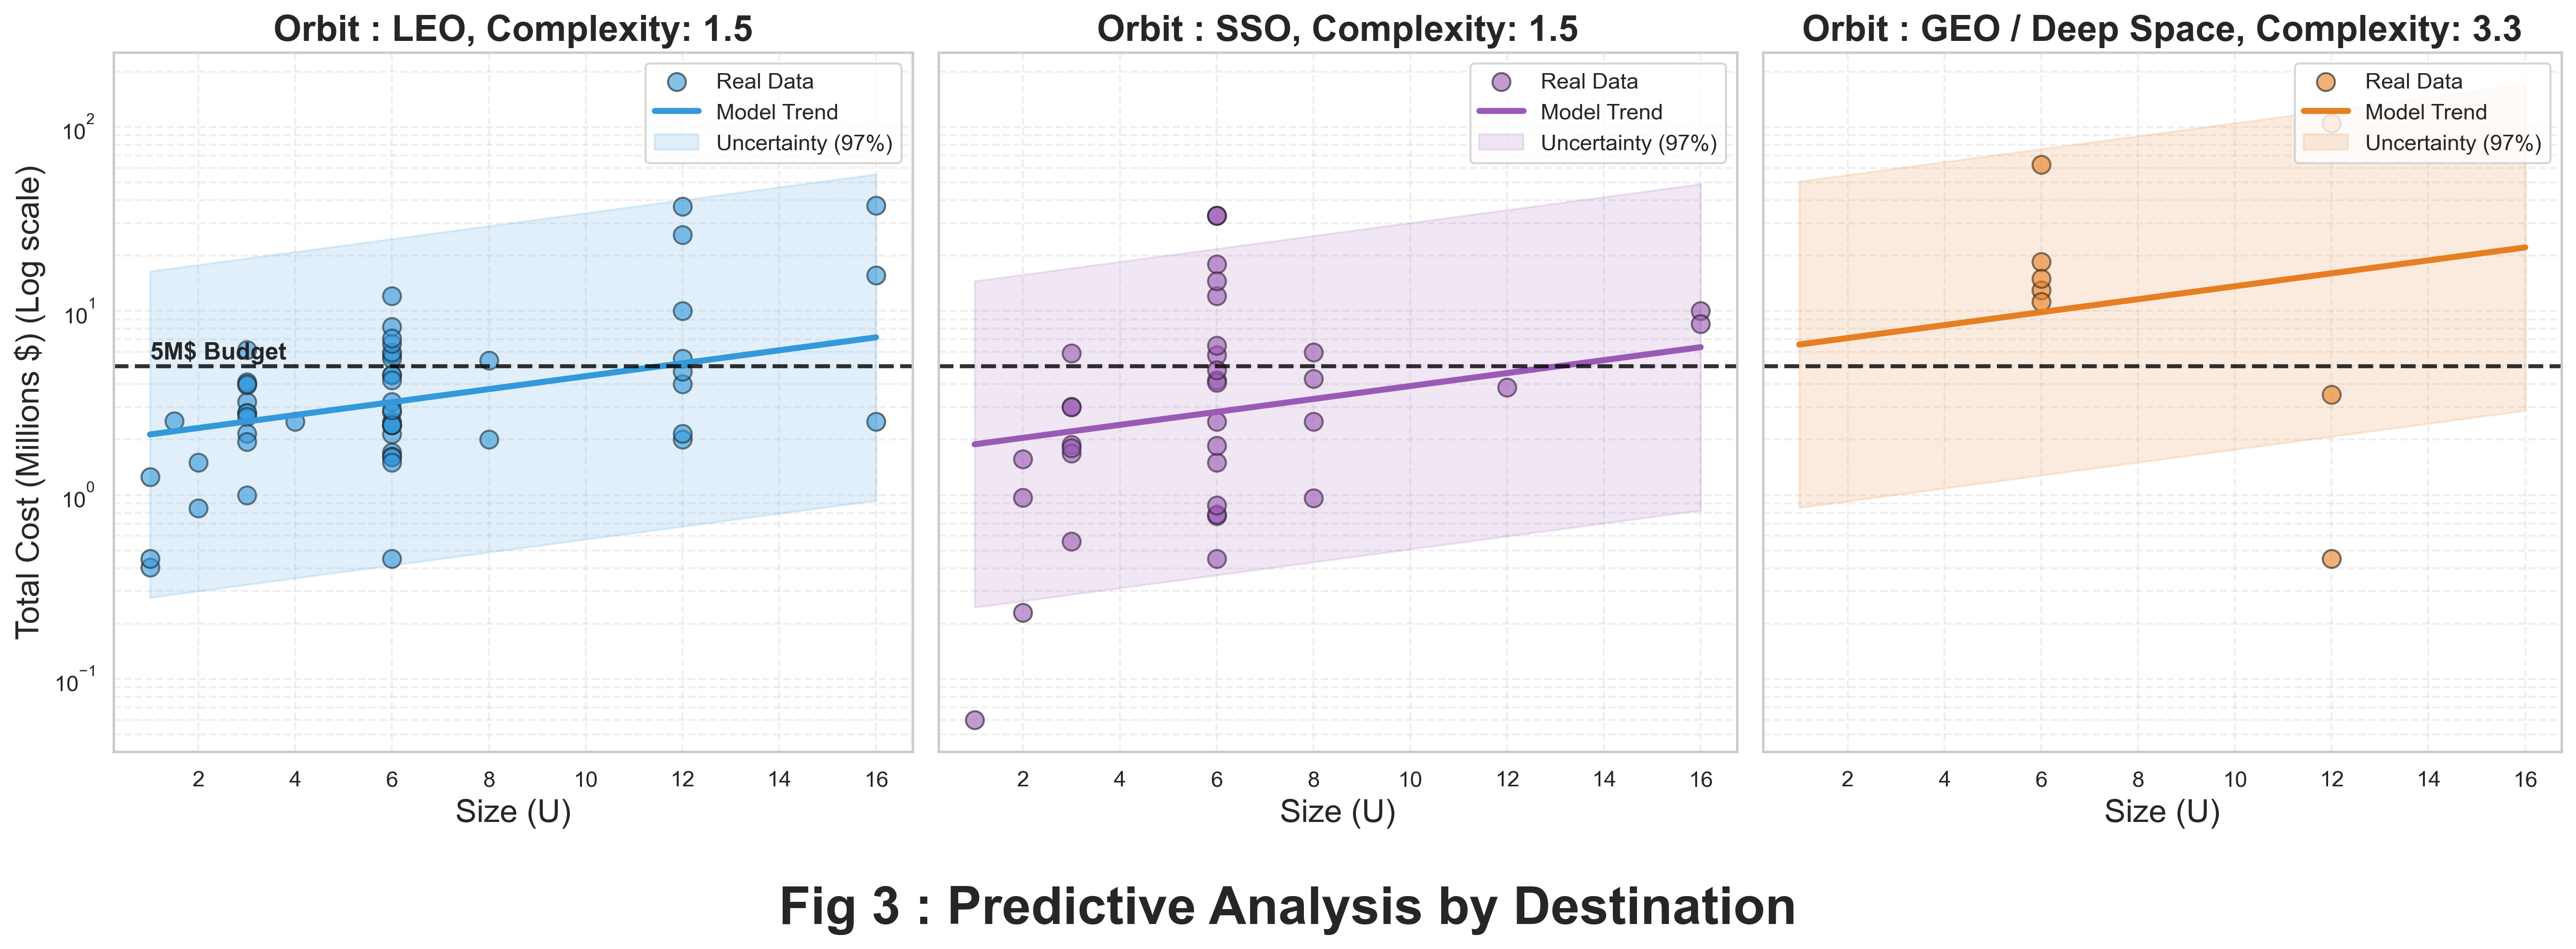

In [22]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# --- 1. Paramètres issus de ton dernier modèle (Summary) ---
# Note : Utilise ici les valeurs exactes de ton dernier "summary"
# Ici j'utilise tes nouvelles catégories fusionnées
alphas = {
    "LEO": -0.601,
    "SSO": -0.696,
    "GEO / Deep Space": -1.044
}
b_size = 0.081
b_complexity = 0.913
b_comm = -0.133
sigma = 1.021

df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")
# On applique la même fusion que dans le modèle pour la cohérence
df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')

# --- 2. Configuration des Subplots ---
orbits_to_plot = ["LEO", "SSO", "GEO / Deep Space"]
colors = {"LEO": "#3498db", "SSO": "#9b59b6", "GEO / Deep Space": "#e67e22"}

fig, axes = plt.subplots(1, 3, figsize=(18, 6), sharey=True, dpi=300)
sizes_range = np.linspace(1, 16, 100)
comp_by_orbit = df.groupby('Orbit_Type')['Complexity_Score'].mean()

for i, orbit in enumerate(orbits_to_plot):
    ax = axes[i]
    if i == 0 : 
        ax.text(1, 5.5, "5M$ Budget", fontsize=12, fontweight='bold')
    
    # a. Tracer les données réelles (Scatter)
    subset = df[df['Orbit_Type'] == orbit]
    ax.scatter(subset['Size in U'], subset['Coût Total (USD)'], 
               color=colors[orbit], alpha=0.6, s=80, edgecolors='k', label='Real Data')
    
    # b. Tracer la ligne de régression (Moyenne)
    # Equation : exp(alpha + beta_size*size + beta_comp*comp_mean + beta_comm*1)
    log_mu = alphas[orbit] + (b_size * sizes_range) + (b_complexity * comp_by_orbit[orbit]) + (b_comm * 1)
    mean_cost = np.exp(log_mu)
    ax.plot(sizes_range, mean_cost, color=colors[orbit], lw=3, label='Model Trend')
    
    # c. Zone d'incertitude (HDI 97% basé sur Sigma)
    # On utilise 2*sigma pour couvrir ~95-97% de la distribution log-normale
    lower = np.exp(log_mu - 2*sigma)
    upper = np.exp(log_mu + 2*sigma)
    ax.fill_between(sizes_range, lower, upper, color=colors[orbit], alpha=0.15, label='Uncertainty (97%)')
    
    # d. Cosmétique par subplot
    ax.set_title(f"Orbit : {orbit}, Complexity: {comp_by_orbit[orbit]:.1f}", fontsize=18, fontweight='bold')
    ax.set_xlabel("Size (U)", fontsize=16)
    ax.set_yscale('log')
    ax.grid(True, which="both", ls="--", alpha=0.3)
    if i == 0:
        ax.set_ylabel("Total Cost (Millions $) (Log scale)", fontsize=16)
    ax.legend(fontsize=11, loc='upper right')
    ax.axhline(5, color='black', linestyle='--', linewidth=2, alpha=0.8)


fig.text(
    0.5, -0.08,
    "Fig 3 : Predictive Analysis by Destination",
    ha='center',
    fontsize=26,
    fontweight='bold'
)
plt.tight_layout()
plt.show()

In [77]:
alphas = {
    "LEO": -0.601,
    "SSO": -0.696,
    "GEO / Deep Space": -1.044,
    "GEO / DS": -1.044
}

complexity = {
    "LEO": 1.2,
    "SSO": 1.5,
    "GEO / Deep Space": 2.2,
    "GEO / DS": 3.2,
}
b_size = 0.081
b_complexity = 0.913
b_comm = -0.133
b_year = 0.046

sigma = 1.021
size = 6
commercial = 1
year = 2026


for i in alphas.keys():
    mu = alphas[i] + b_size*size + b_complexity*complexity[i] + b_comm*commercial + b_year*(year - 2024)
    price = np.exp(mu)
    low, high = np.exp(mu-sigma), np.exp(mu+sigma)
    print(mu)
    print(f"Predicted Cost for {i} : {price:.2f} M$ (68% HDI: {low:.2f} - {high:.2f} M$)")

0.9395999999999999
Predicted Cost for LEO : 2.56 M$ (68% HDI: 0.92 - 7.10 M$)
1.1185
Predicted Cost for SSO : 3.06 M$ (68% HDI: 1.10 - 8.50 M$)
1.4096000000000004
Predicted Cost for GEO / Deep Space : 4.09 M$ (68% HDI: 1.47 - 11.37 M$)
2.3226
Predicted Cost for GEO / DS : 10.20 M$ (68% HDI: 3.68 - 28.32 M$)


In [43]:
import numpy as np
import pandas as pd

# On définit l'incertitude du modèle (basée sur ton sigma ~ 1.0)
# Dans un modèle log-normal, l'intervalle à 95% est environ [mu - 2*sigma, mu + 2*sigma]
sigma_val = 1.021 

success_count = 0
total_points = len(df)

for i, row in df.iterrows():
    # 1. Calcul de la prédiction centrale (mu)
    log_mu = alphas[row['Orbit_Type']] + \
             (b_size * row['Size in U']) + \
             (b_complexity * row['Complexity_Score']) + \
             (b_comm * row['Is_Commercial'])
    
    # 2. Calcul des bornes (95% de probabilité)
    # On reste en log pour comparer, c'est plus stable
    log_real = np.log(row['Coût Total (USD)'])
    lower_bound = log_mu - 2 * sigma_val
    upper_bound = log_mu + 2 * sigma_val
    
    # 3. Vérification : le coût réel est-il dans l'intervalle ?
    if lower_bound <= log_real <= upper_bound:
        success_count += 1

coverage_rate = (success_count / total_points) * 100

print(f"Taux de couverture du modèle : {coverage_rate:.1f}%")

Taux de couverture du modèle : 97.8%


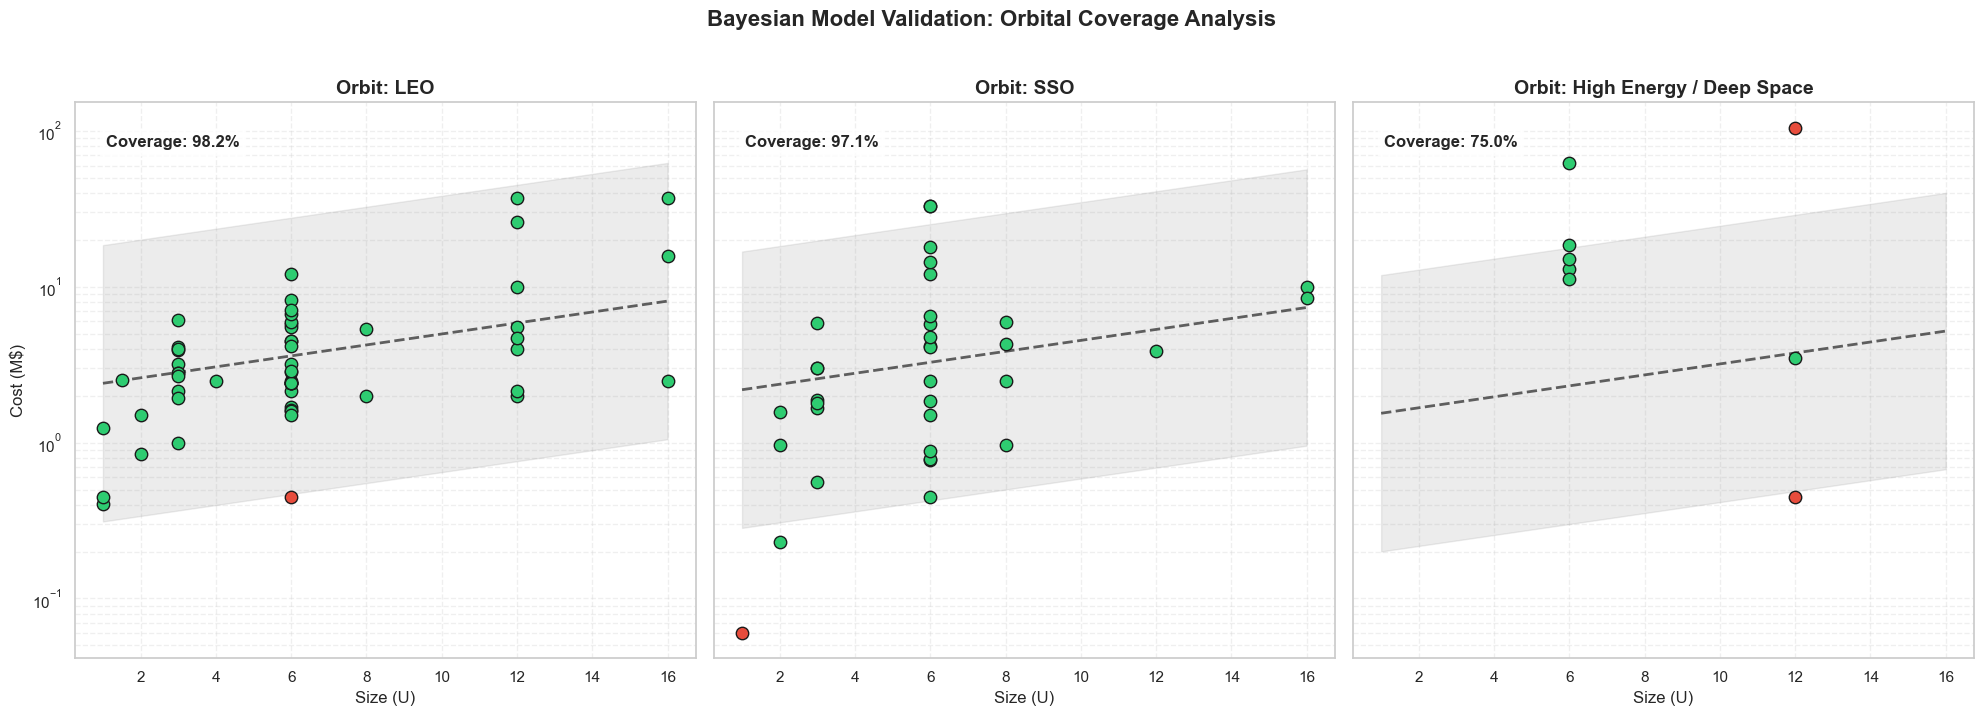

In [44]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

# 1. Tes paramètres (Summary)
alphas = {"LEO": -0.601, "SSO": -0.696, "High Energy / Deep Space": -1.044}
b_size, b_complexity, b_comm, sigma = 0.081, 0.913, -0.133, 1.021

# 2. Préparation des données
df = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")
df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'High Energy / Deep Space')
df = df.dropna(subset=['Coût Total (USD)', 'Size in U', 'Complexity_Score'])

# 3. Création des Subplots
orbits = ["LEO", "SSO", "High Energy / Deep Space"]
fig, axes = plt.subplots(1, 3, figsize=(20, 7), sharey=True)
sizes_range = np.linspace(1, 16, 100)
comp_mean = df['Complexity_Score'].mean()

for i, orbit in enumerate(orbits):
    ax = axes[i]
    subset = df[df['Orbit_Type'] == orbit].copy()
    
    # Calcul de la zone d'incertitude (94% HDI approx)
    log_mu_line = alphas[orbit] + (b_size * sizes_range) + (b_complexity * comp_mean) + (b_comm * 1)
    ax.fill_between(sizes_range, np.exp(log_mu_line - 2*sigma), np.exp(log_mu_line + 2*sigma), 
                    color='gray', alpha=0.15, label='94% Prediction Interval')
    ax.plot(sizes_range, np.exp(log_mu_line), color='black', lw=2, linestyle='--', alpha=0.6)

    # Vérification pour chaque point du subset
    in_idx, out_idx = [], []
    for idx, row in subset.iterrows():
        log_mu_point = alphas[orbit] + (b_size * row['Size in U']) + (b_complexity * row['Complexity_Score']) + (b_comm * row['Is_Commercial'])
        log_real = np.log(row['Coût Total (USD)'])
        # Si le point est dans l'intervalle [mu - 2sigma, mu + 2sigma]
        if (log_mu_point - 2*sigma) <= log_real <= (log_mu_point + 2*sigma):
            in_idx.append(idx)
        else:
            out_idx.append(idx)
    
    # Affichage des points (Vert = Succès, Rouge = Échec)
    ax.scatter(subset.loc[in_idx, 'Size in U'], subset.loc[in_idx, 'Coût Total (USD)'], 
               color='#2ecc71', s=80, edgecolors='k', label='Within Interval', zorder=3)
    ax.scatter(subset.loc[out_idx, 'Size in U'], subset.loc[out_idx, 'Coût Total (USD)'], 
               color='#e74c3c', s=80, edgecolors='k', label='Outlier', zorder=3)

    # Calcul du score local
    score = len(in_idx) / len(subset) * 100
    ax.text(0.05, 0.92, f"Coverage: {score:.1f}%", transform=ax.transAxes, 
            fontsize=12, fontweight='bold', bbox=dict(facecolor='white', alpha=0.8))

    ax.set_title(f"Orbit: {orbit}", fontsize=14, fontweight='bold')
    ax.set_yscale('log')
    ax.set_xlabel("Size (U)")
    if i == 0: ax.set_ylabel("Cost (M$)")
    ax.grid(True, which="both", ls="--", alpha=0.3)

plt.suptitle("Bayesian Model Validation: Orbital Coverage Analysis", fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

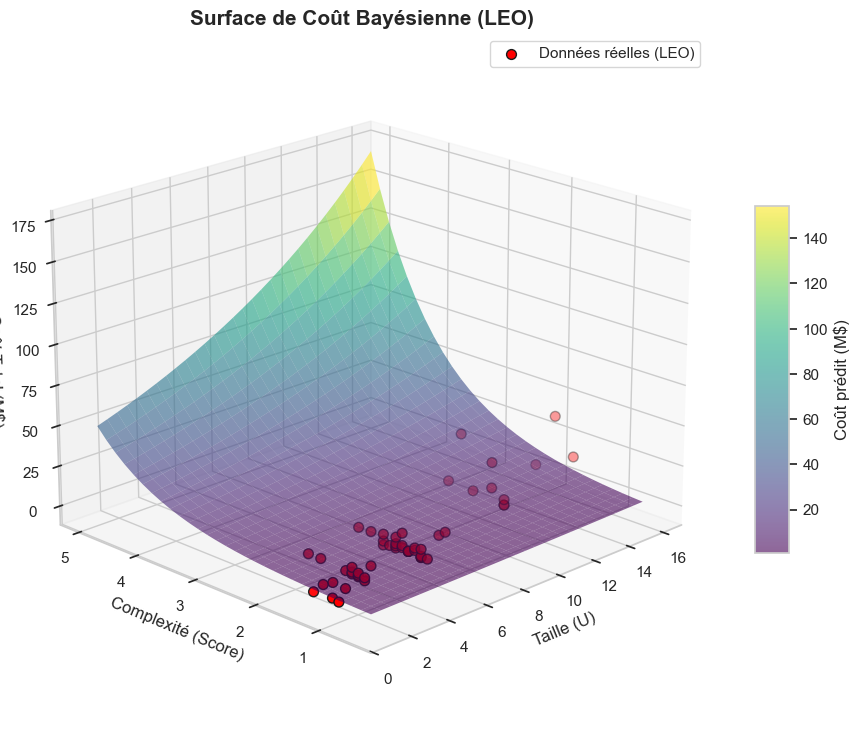

In [45]:
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 1. Préparation des données (on utilise les moyennes pour une orbite donnée, ex: LEO)
orbit_target = "LEO"
alpha_fix = alphas[orbit_target]

# Création d'une grille pour la surface
x_size = np.linspace(1, 16, 30)
y_comp = np.linspace(0.5, 5, 30)
X, Y = np.meshgrid(x_size, y_comp)

# Calcul du coût prédit (Z) : exp(alpha + b_s*X + b_c*Y + b_comm*1)
Z = np.exp(alpha_fix + b_size * X + b_complexity * Y + b_comm * 1)

# 2. Création du graphique 3D
fig = plt.figure(figsize=(12, 9))
ax = fig.add_subplot(111, projection='3d')

# Dessin de la surface de prédiction
surf = ax.plot_surface(X, Y, Z, cmap='viridis', alpha=0.6, edgecolor='none')

# 3. Ajout des points réels (uniquement pour l'orbite choisie pour la cohérence)
subset = df[df['Orbit_Type'] == orbit_target]
ax.scatter(subset['Size in U'], subset['Complexity_Score'], subset['Coût Total (USD)'], 
           color='red', s=50, edgecolors='k', label=f'Données réelles ({orbit_target})')

# 4. Cosmétique
ax.set_title(f"Surface de Coût Bayésienne ({orbit_target})", fontsize=15, fontweight='bold')
ax.set_xlabel('Taille (U)', fontsize=12)
ax.set_ylabel('Complexité (Score)', fontsize=12)
ax.set_zlabel('Coût Total (M$)', fontsize=12)

# On passe le Z en log pour mieux voir si l'écart de prix est géant
# ax.set_zscale('log') # Optionnel selon le rendu

ax.view_init(elev=20, azim=-135) # Oriente la vue pour bien voir la pente
plt.colorbar(surf, ax=ax, shrink=0.5, aspect=10, label='Coût prédit (M$)')
plt.legend()
plt.show()

README

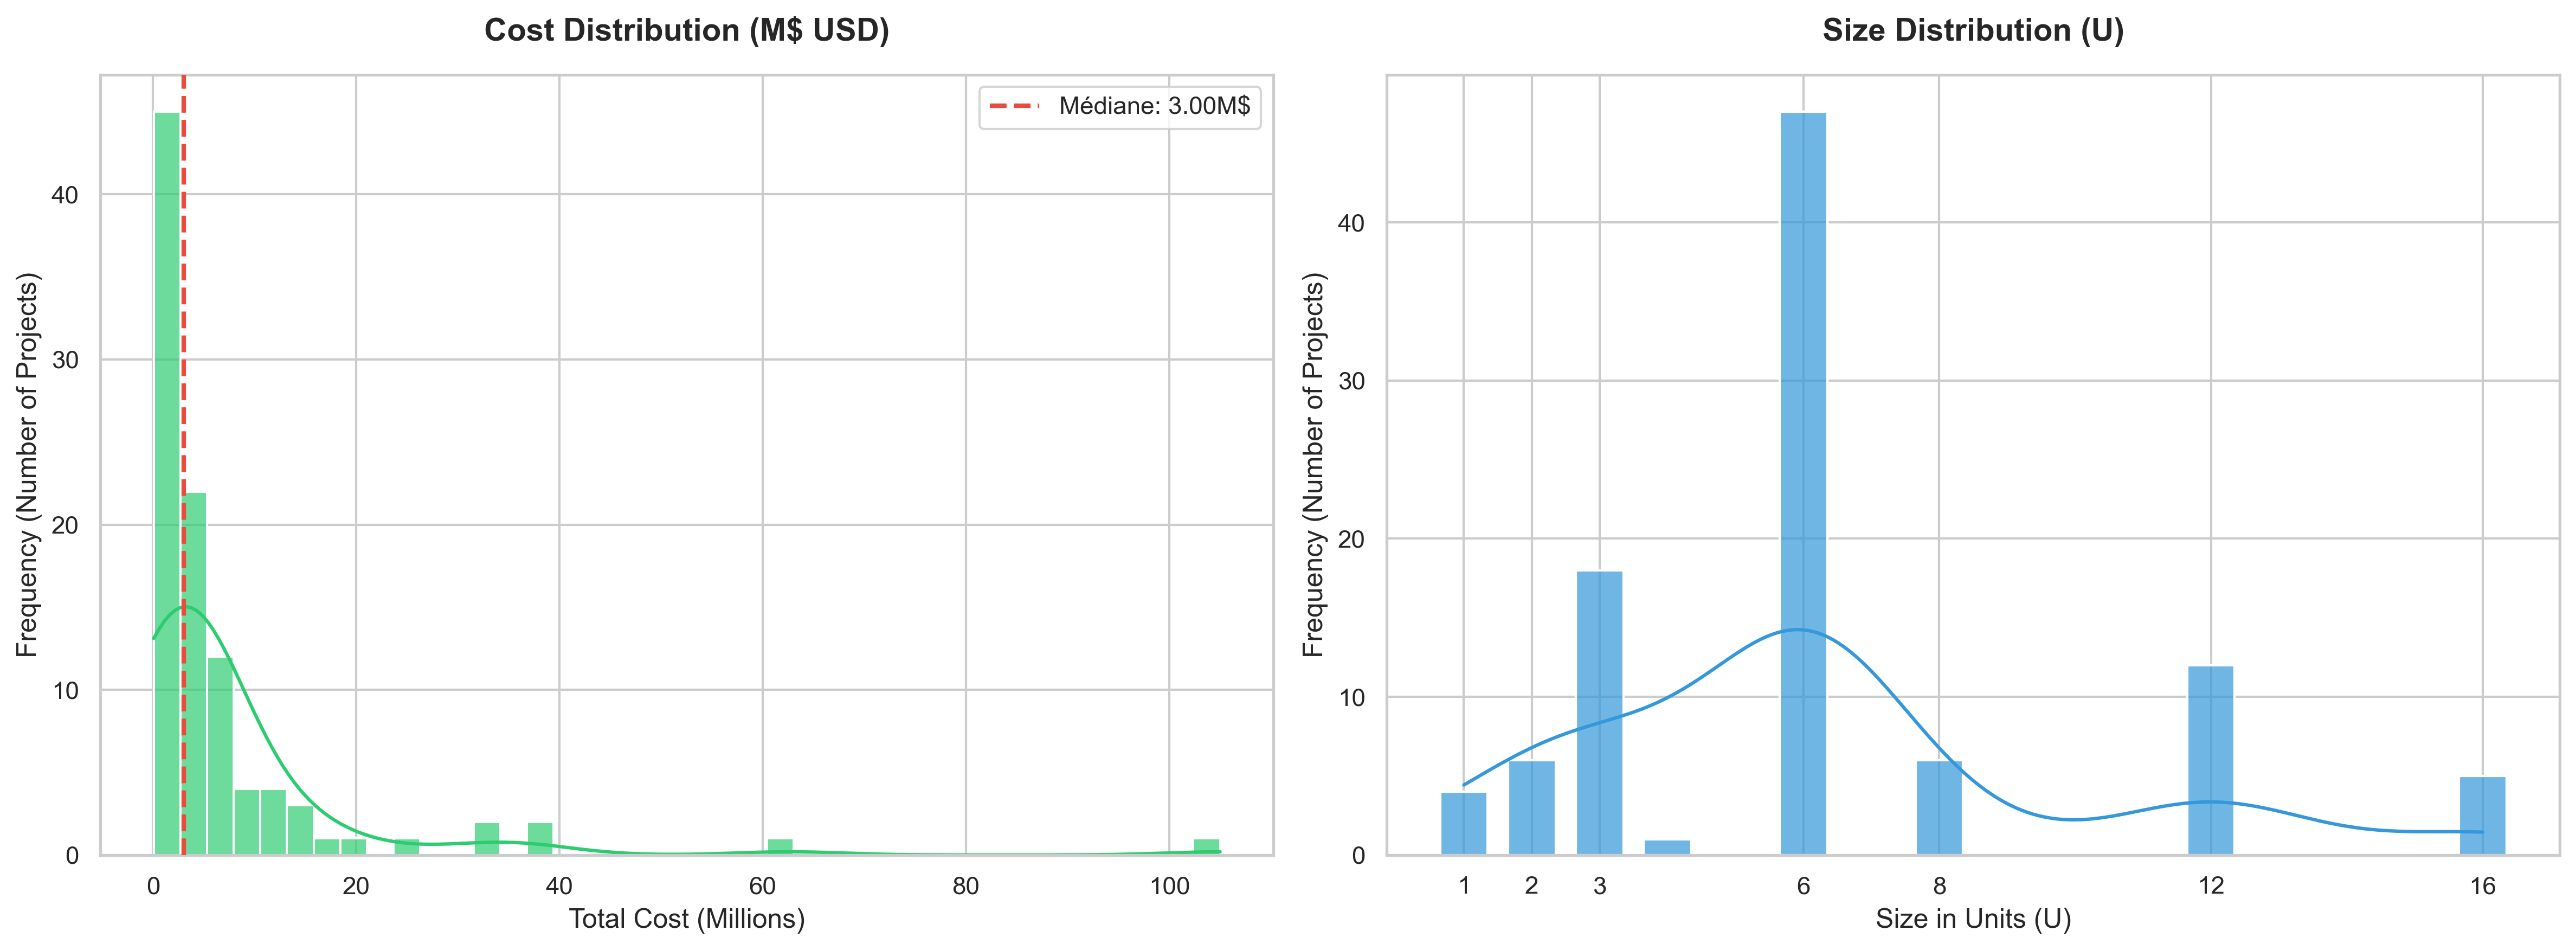

In [6]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6), dpi=300)
sns.set_theme(style="whitegrid") # Grille propre en arrière-plan

# --- GAUCHE : Distribution des COÛTS (Vert Émeraude) ---
sns.histplot(df['Coût Total (USD)'], kde=True, color="#2ecc71", ax=ax1, bins=40, alpha=0.7)
ax1.set_title('Cost Distribution (M$ USD)', fontsize=14, fontweight='bold', pad=15)
ax1.set_xlabel('Total Cost (Millions)', fontsize=12)
ax1.set_ylabel('Frequency (Number of Projects)', fontsize=12)

# Ajout de la médiane en rouge
median_cost = df['Coût Total (USD)'].median()
ax1.axvline(median_cost, color='#e74c3c', linestyle='--', linewidth=2, label=f'Médiane: {median_cost:.2f}M$', zorder=3)
ax1.legend()

# --- DROITE : Distribution des TAILLES (Bleu Ciel) ---
# Note : discrete=True est crucial ici pour que les barres s'alignent sur 1, 2, 3, 6...
sns.histplot(df['Size in U'], color="#3498db", ax=ax2, discrete=True, shrink=0.7, kde=True, alpha=0.7)
ax2.set_title('Size Distribution (U)', fontsize=14, fontweight='bold', pad=15)
ax2.set_xlabel('Size in Units (U)', fontsize=12)
ax2.set_ylabel('Frequency (Number of Projects)', fontsize=12)

# On force l'affichage des paliers standards des CubeSats
standard_units = [1, 2, 3, 6, 8, 12, 16]
ax2.set_xticks(standard_units)


# --- 3. Finition et Affichage ---
plt.tight_layout()
plt.show()

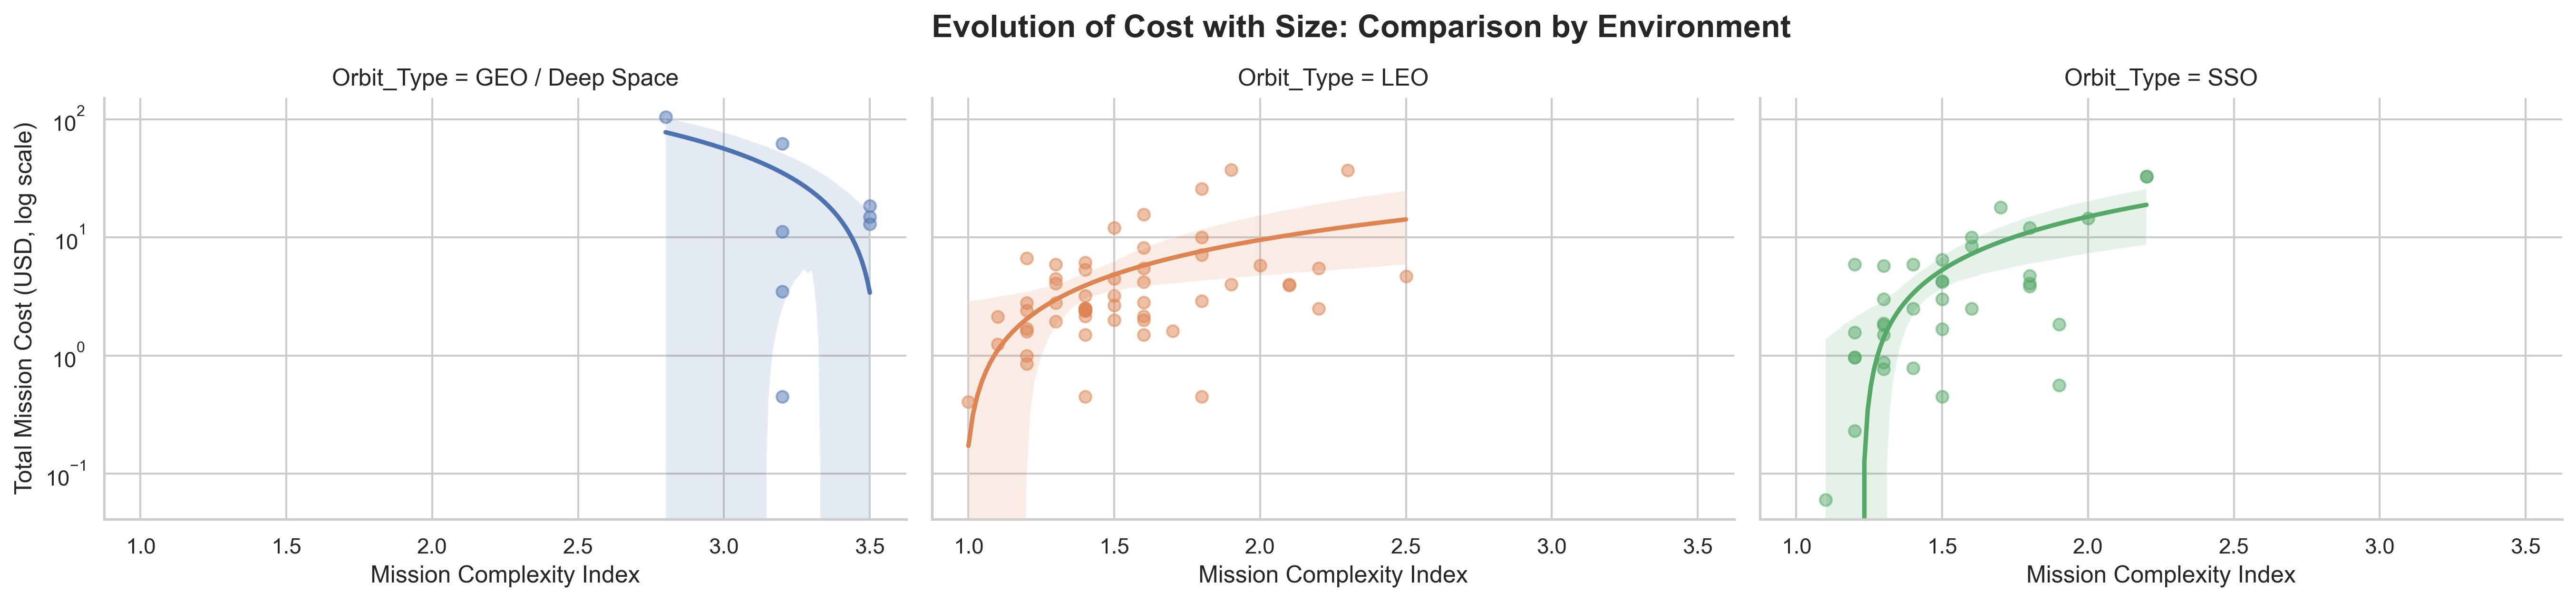

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# --- 1. CONFIGURATION ---
sns.set_theme(style="whitegrid")
plt.rcParams['figure.dpi'] = 300 

# --- 2. CHARGEMENT ET PRÉPARATION ---
file_path = "ESA_CNES - CubeSeat Dataset - data.csv"
df = pd.read_csv(file_path)

# Nettoyage et conversion
df['Coût Total (USD)'] = pd.to_numeric(df['Coût Total (USD)'], errors='coerce')
df = df.dropna(subset=['Coût Total (USD)'])
df['Size in U'] = df['Size in U'].astype(float)
df['Orbit_Type'] = df['Orbit_Type'].replace(['GEO', 'Deep Space'], 'GEO / Deep Space')
df['Orbit_Type'] = df['Orbit_Type'].astype('category')

# --- 5. FACET GRID : TAILLE VS COÛT PAR ORBITE ---
# Pour voir si 1U en LEO coûte la même chose qu'un 1U en Deep Space
g = sns.FacetGrid(df, col="Orbit_Type", hue="Orbit_Type", col_wrap=4, height=4, aspect=1.5)
g.map(sns.regplot, "Complexity_Score", "Coût Total (USD)", scatter_kws={'alpha':0.5})
g.set(yscale="log")
g.set_axis_labels(
    "Mission Complexity Index", 
    "Total Mission Cost (USD, log scale)"
)
g.fig.suptitle("Evolution of Cost with Size: Comparison by Environment", 
               fontsize=16, fontweight='bold', y=1.05, x=0.4)
plt.show()

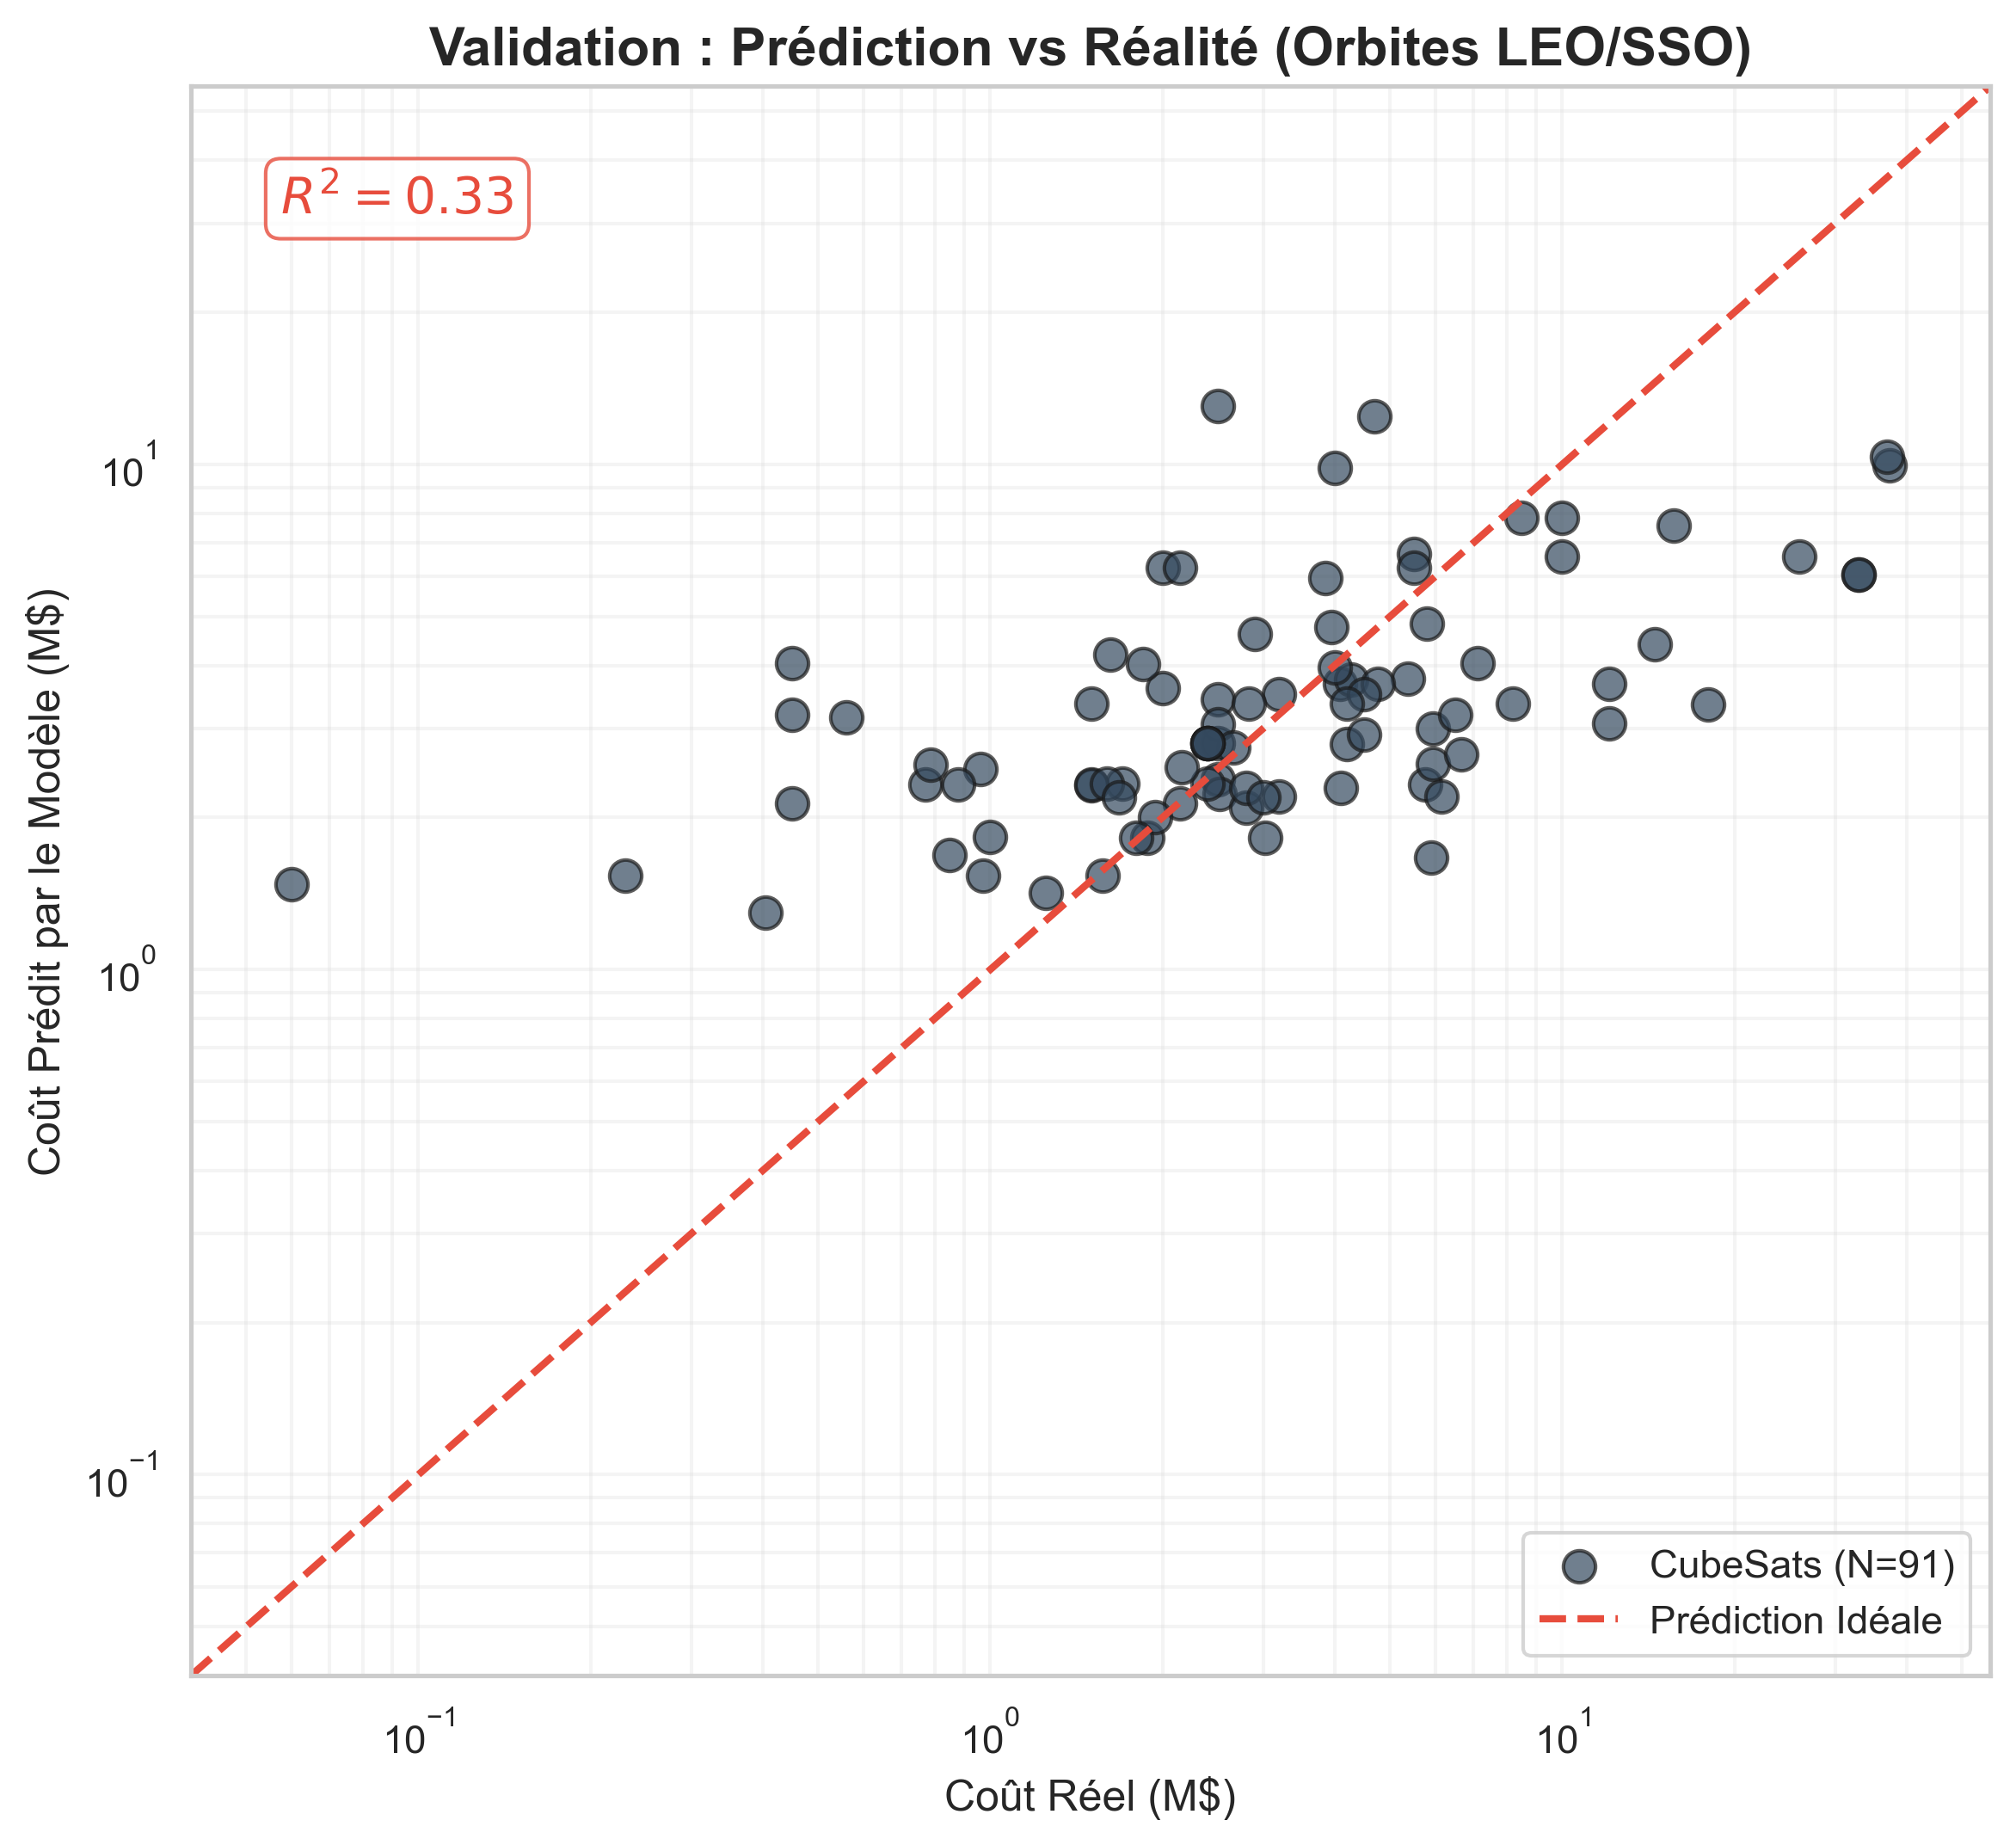

Nombre de points analysés : 91
R² obtenu : 0.3262


In [25]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.metrics import r2_score

# 1. Chargement et FILTRAGE IMMEDIAT
df_full = pd.read_csv("ESA_CNES - CubeSeat Dataset - data.csv")

# On ne garde que le cœur du marché (LEO et SSO) pour la précision
df = df_full[df_full['Orbit_Type'].isin(['LEO', 'SSO'])].copy()

# Nettoyage des valeurs manquantes ou aberrantes
df = df.dropna(subset=['Coût Total (USD)', 'Size in U', 'Complexity_Score'])
df = df[df['Coût Total (USD)'] > 0]

# 2. Paramètres issus de ton dernier modèle (Summary)
# Assure-toi que ces valeurs correspondent bien à ton dernier run PyMC
alphas = {
    "LEO": -0.601,
    "SSO": -0.696
}
b_size = 0.081
b_complexity = 0.913
b_comm = -0.133

# 3. Calcul des prédictions (uniquement sur le nouveau DataFrame filtré)
y_real = df['Coût Total (USD)'].values
y_pred = []

for i, row in df.iterrows():
    orbit = row['Orbit_Type']
    # Calcul du log_mu selon la formule du modèle
    log_mu = alphas[orbit] + \
             (b_size * row['Size in U']) + \
             (b_complexity * row['Complexity_Score']) + \
             (b_comm * row['Is_Commercial'])
    y_pred.append(np.exp(log_mu))

y_pred = np.array(y_pred)

# 4. Calcul du R² sur l'échelle log
# C'est ici qu'on voit si le focus sur LEO/SSO améliore la corrélation
r2 = r2_score(np.log(y_real), np.log(y_pred))

# 5. Graphique de Validation
plt.figure(figsize=(9, 8))
plt.scatter(y_real, y_pred, alpha=0.7, edgecolors='k', s=80, color='#34495e', label=f'CubeSats (N={len(df)})')

# Droite y = x
min_plot = min(y_real.min(), y_pred.min()) / 1.5
max_plot = max(y_real.max(), y_pred.max()) * 1.5
plt.plot([min_plot, max_plot], [min_plot, max_plot], color='#e74c3c', linestyle='--', lw=2, label='Prédiction Idéale')

plt.xscale('log')
plt.yscale('log')
plt.xlim(min_plot, max_plot)
plt.ylim(min_plot, max_plot)

plt.title("Validation : Prédiction vs Réalité (Orbites LEO/SSO)", fontsize=15, fontweight='bold')
plt.xlabel("Coût Réel (M$)", fontsize=12)
plt.ylabel("Coût Prédit par le Modèle (M$)", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.2)

# Affichage du R²
plt.annotate(f"$R^2 = {r2:.2f}$", xy=(0.05, 0.92), xycoords='axes fraction', 
             fontsize=14, fontweight='bold', color='#e74c3c', 
             bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="#e74c3c", alpha=0.8))

plt.legend(loc='lower right')
plt.show()

print(f"Nombre de points analysés : {len(df)}")
print(f"R² obtenu : {r2:.4f}")

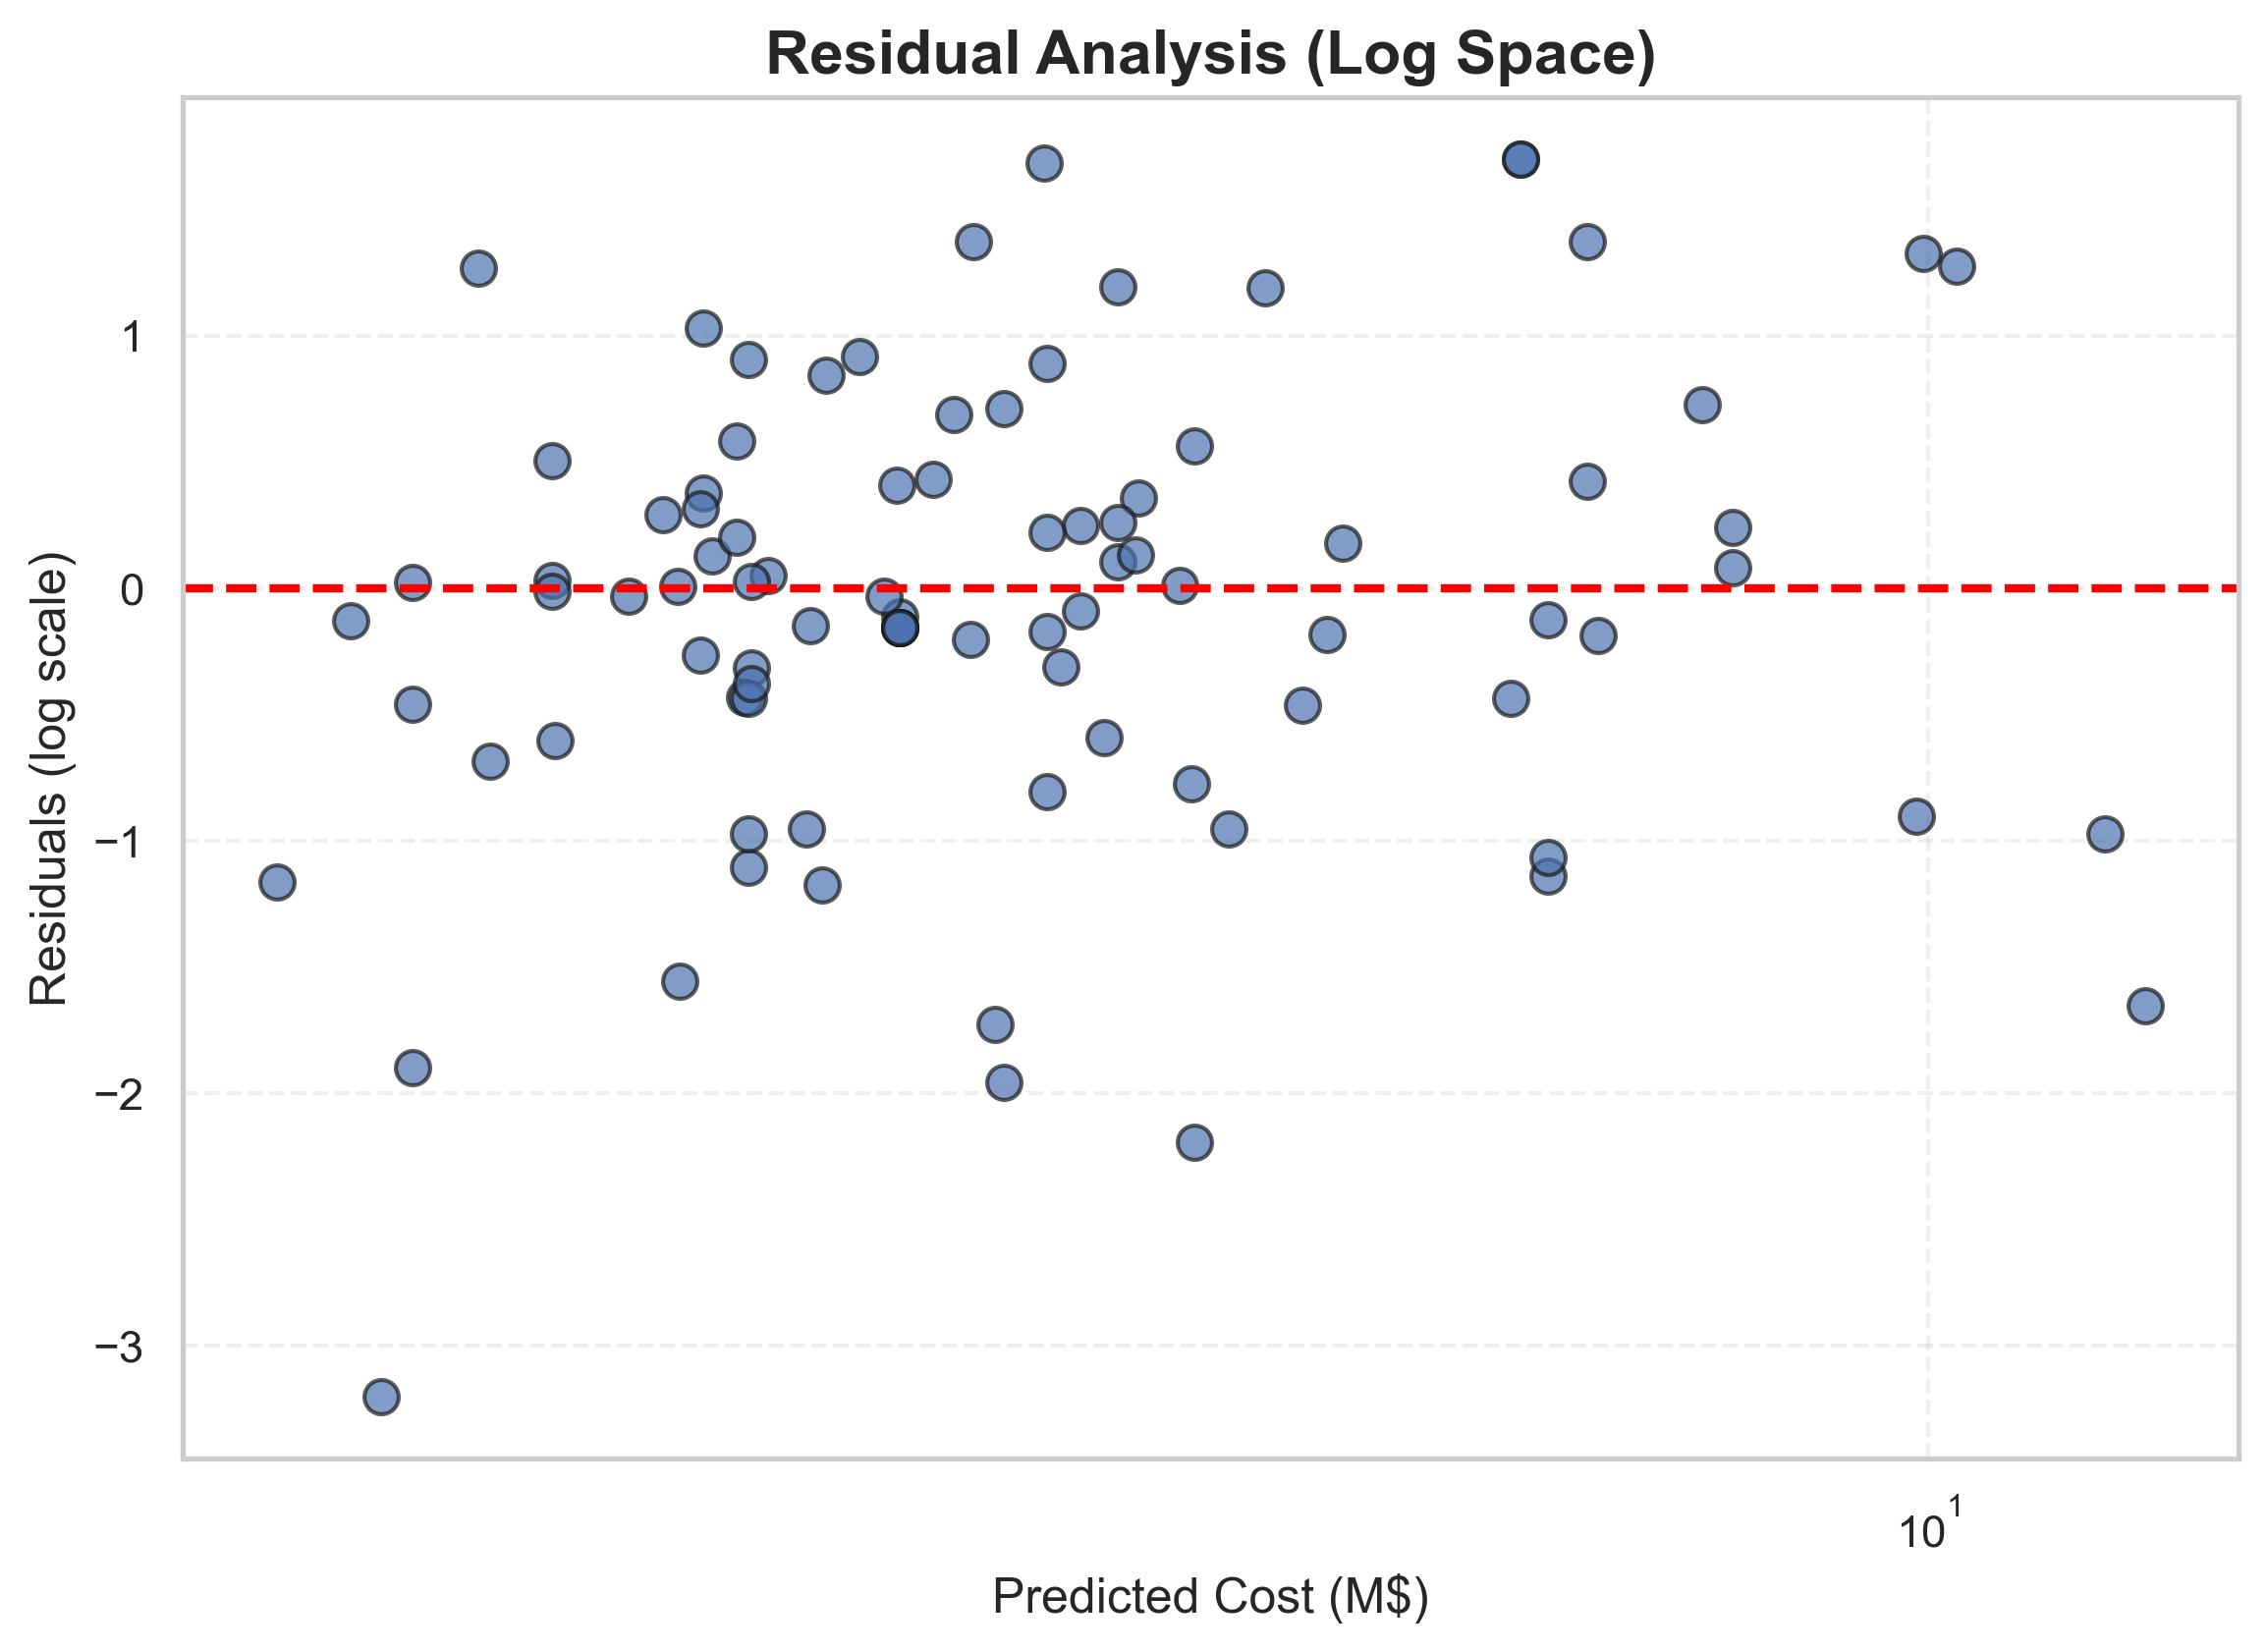

In [23]:
# --- RESIDUALS (log space) ---
residuals = np.log(y_real) - np.log(y_pred)

plt.figure(figsize=(9, 6))
plt.scatter(y_pred, residuals, alpha=0.7, edgecolors='k', s=70)

plt.axhline(0, color='red', linestyle='--', linewidth=2)

plt.xscale('log')
plt.title("Residual Analysis (Log Space)", fontsize=15, fontweight='bold')
plt.xlabel("Predicted Cost (M$)", fontsize=12)
plt.ylabel("Residuals (log scale)", fontsize=12)

plt.grid(True, linestyle='--', alpha=0.3)
plt.show()


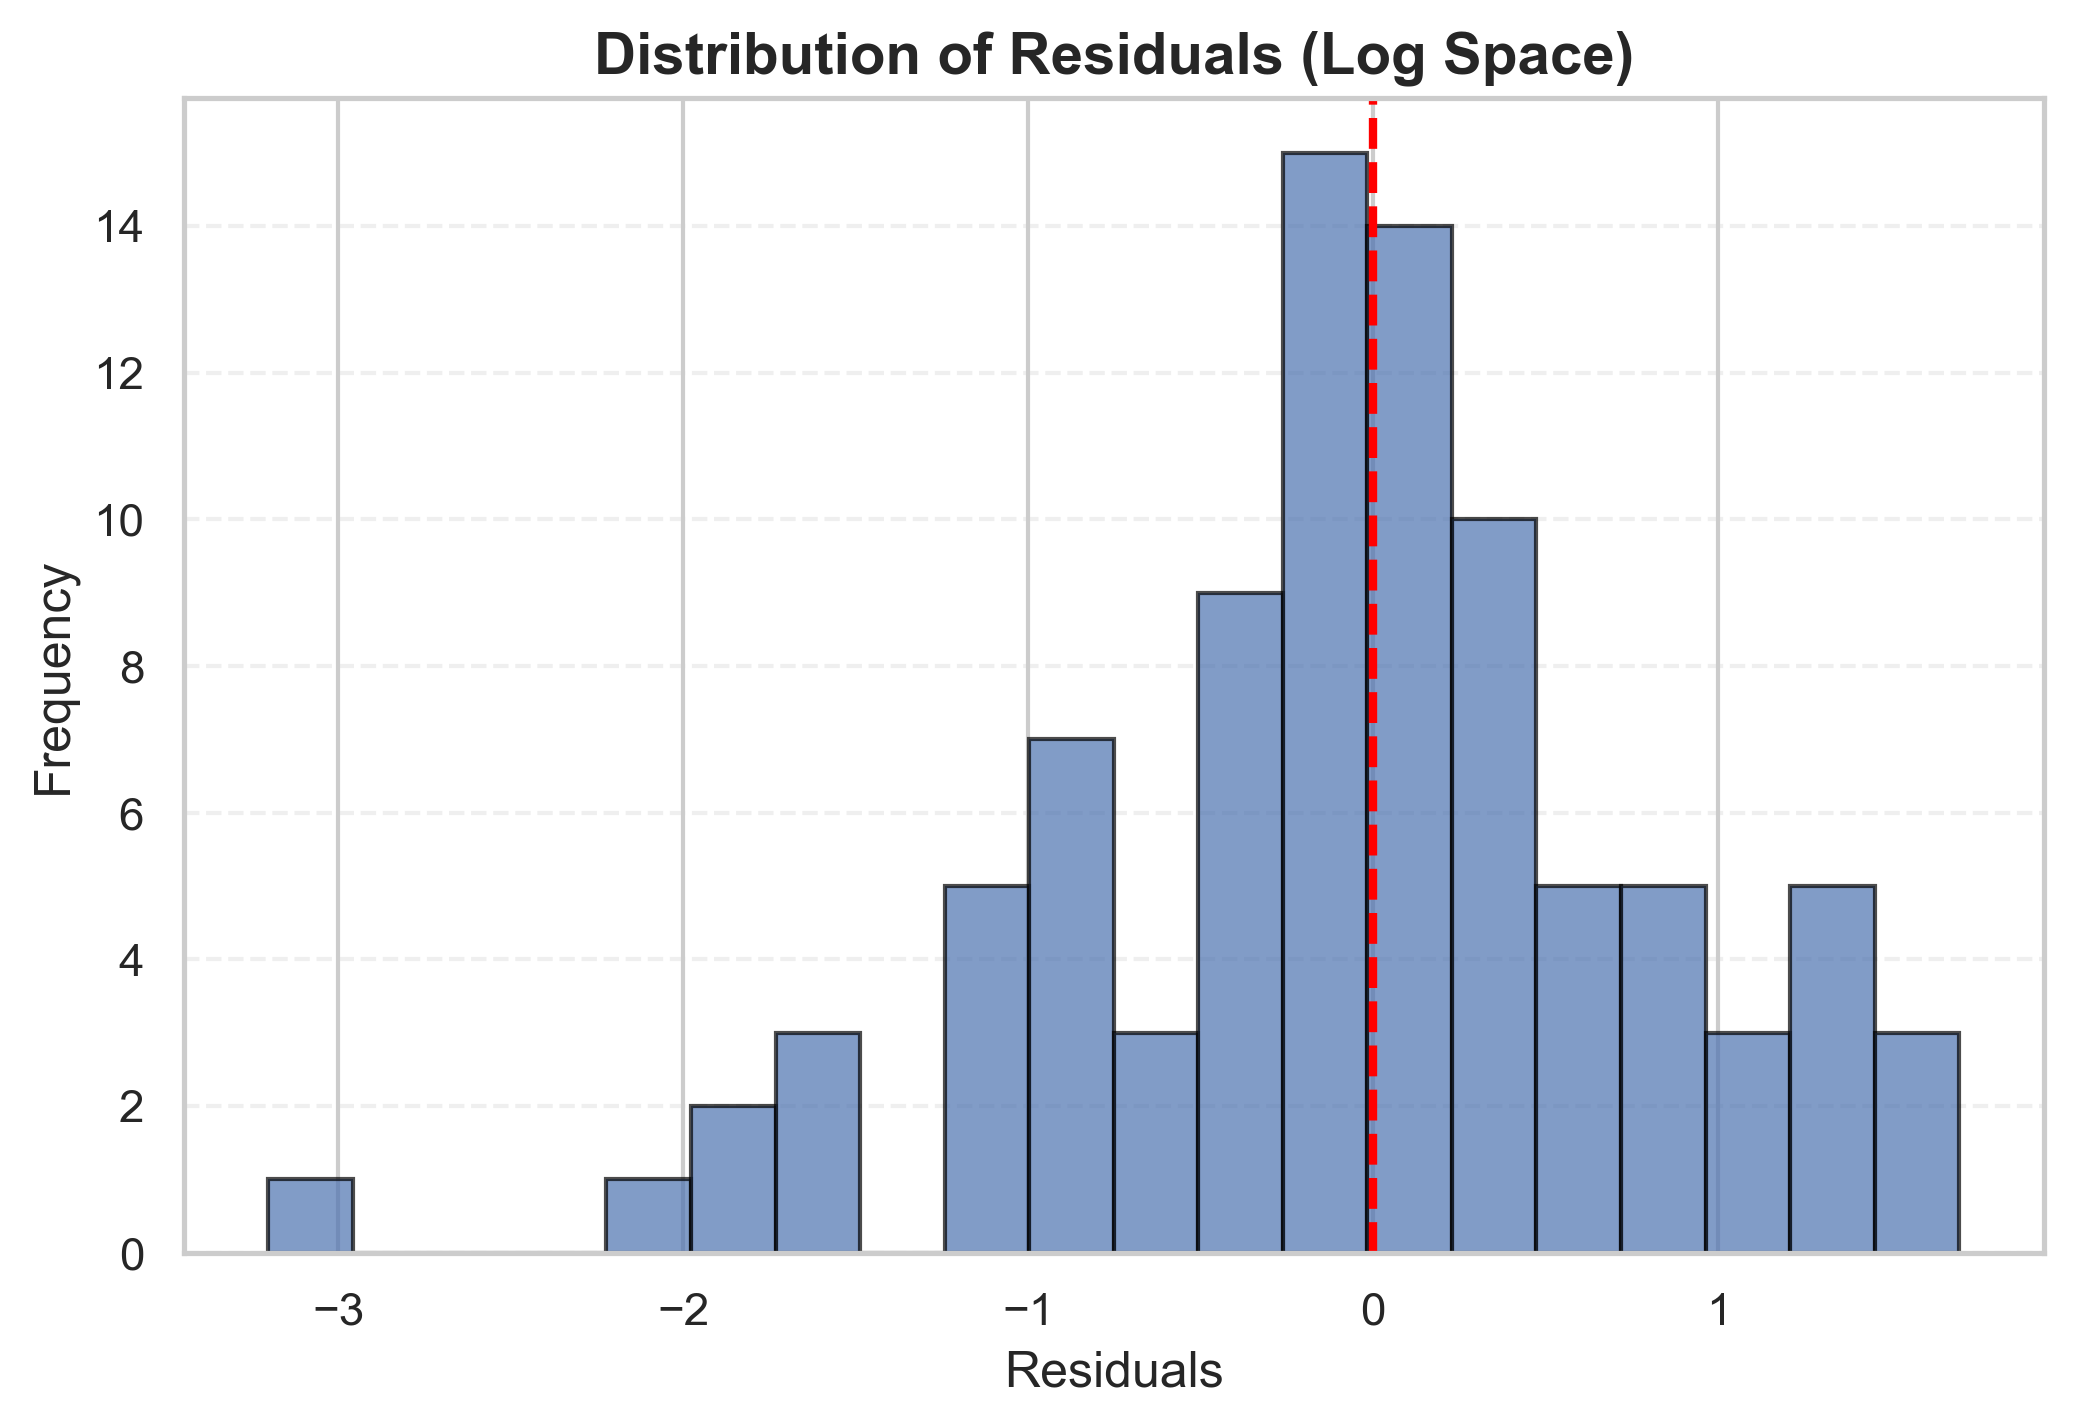

In [24]:
plt.figure(figsize=(8, 5))

plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--', linewidth=2)

plt.title("Distribution of Residuals (Log Space)", fontsize=14, fontweight='bold')
plt.xlabel("Residuals", fontsize=12)
plt.ylabel("Frequency", fontsize=12)

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


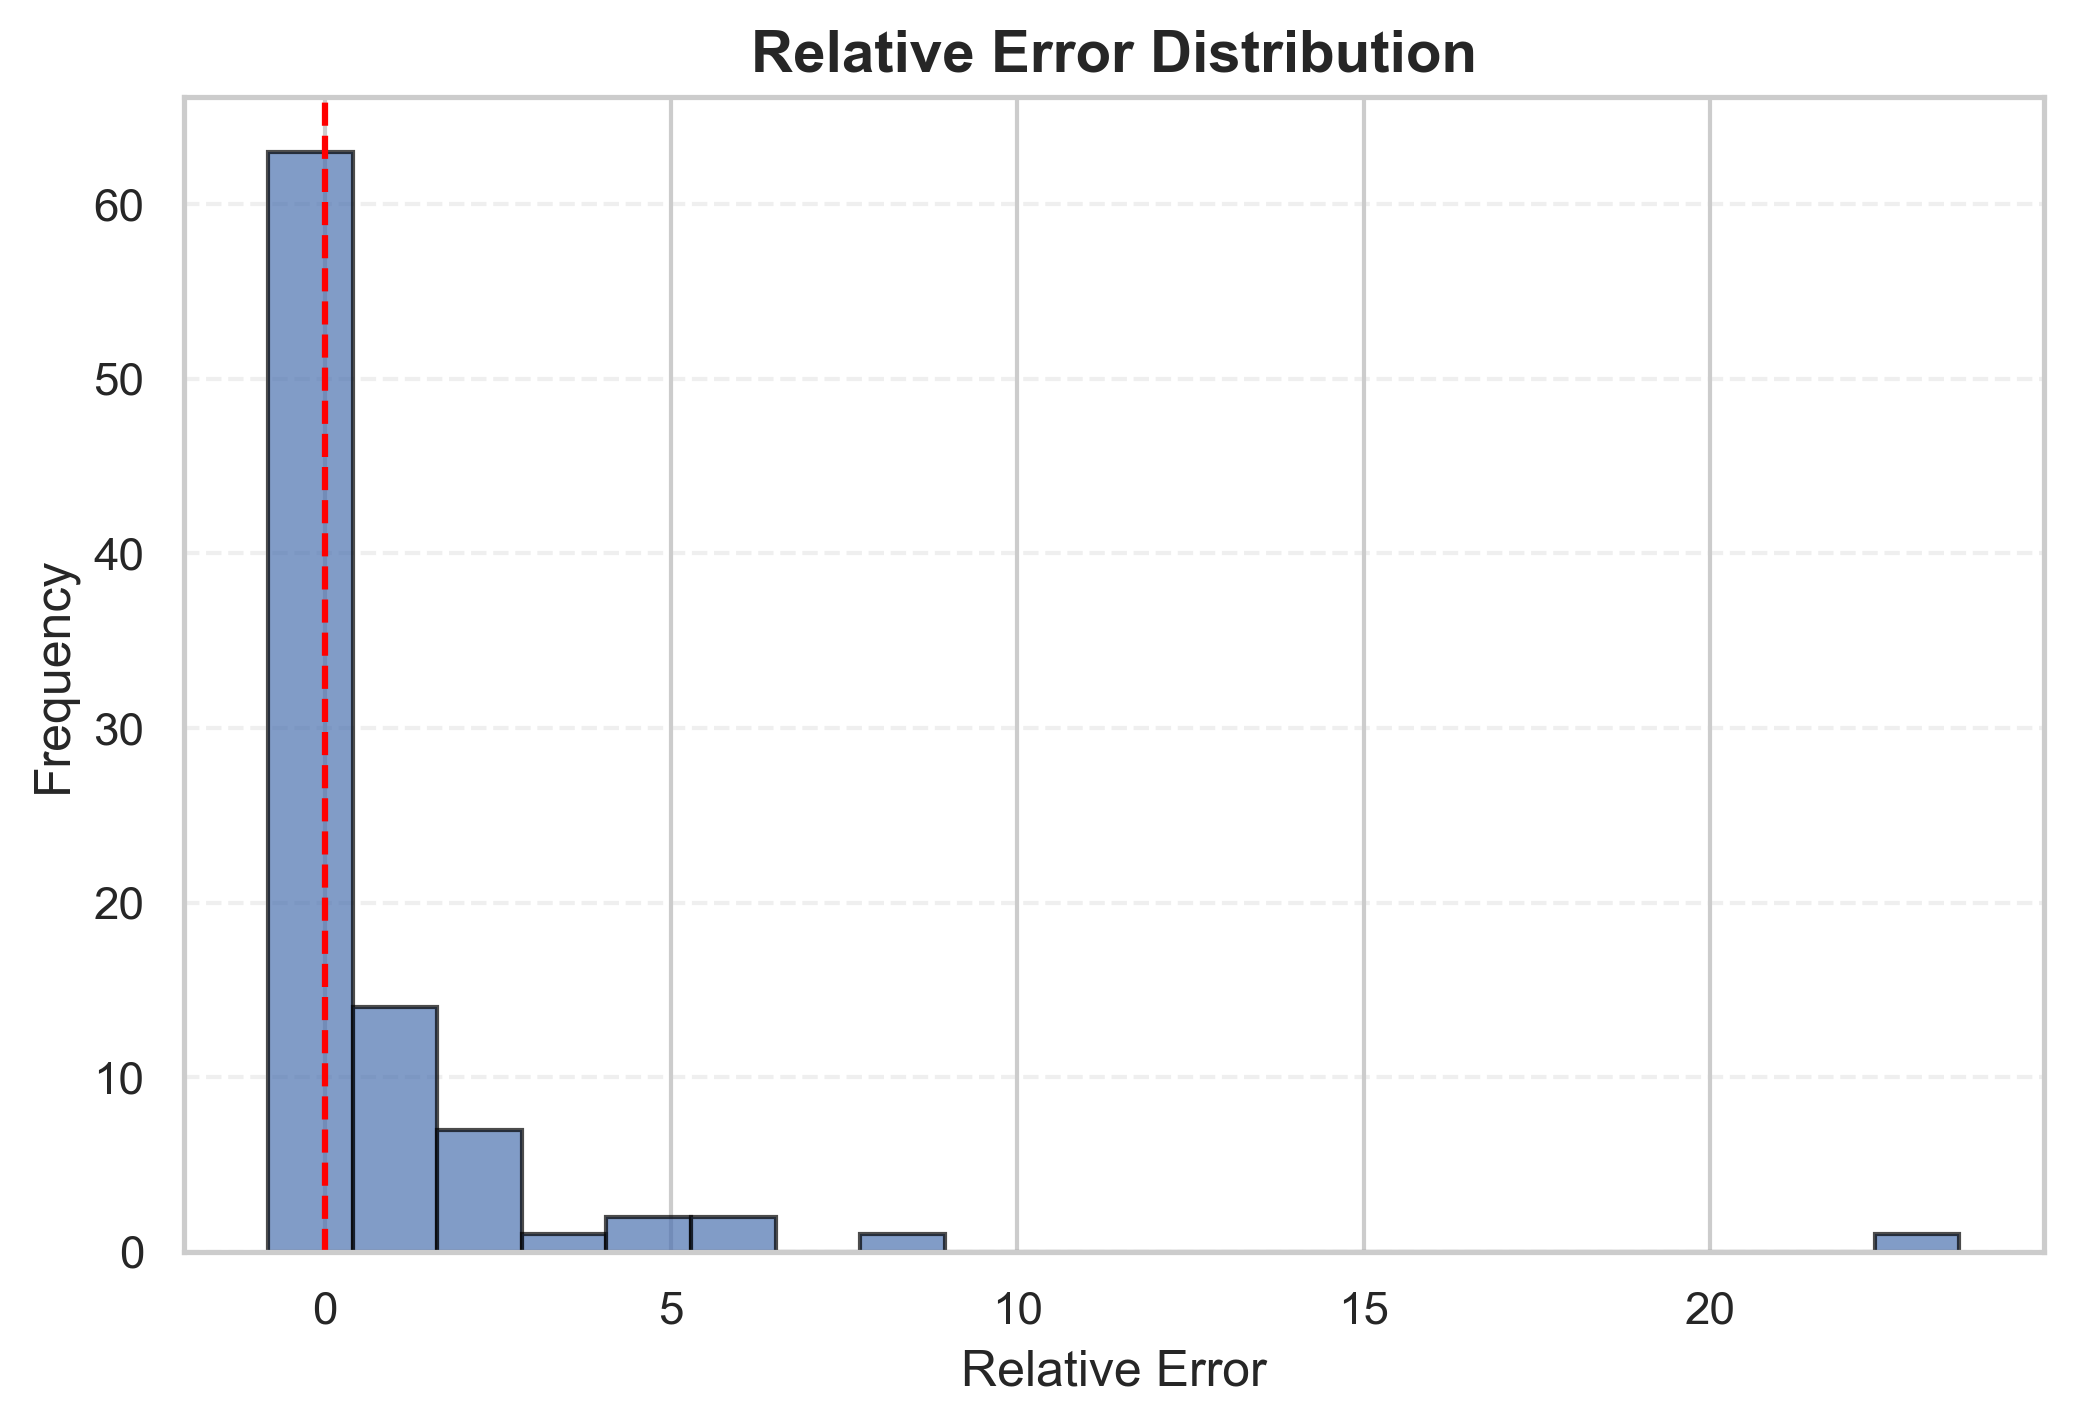

In [26]:
relative_error = (y_pred - y_real) / y_real

plt.figure(figsize=(8, 5))

plt.hist(relative_error, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(0, color='red', linestyle='--')

plt.title("Relative Error Distribution", fontsize=14, fontweight='bold')
plt.xlabel("Relative Error")
plt.ylabel("Frequency")

plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()


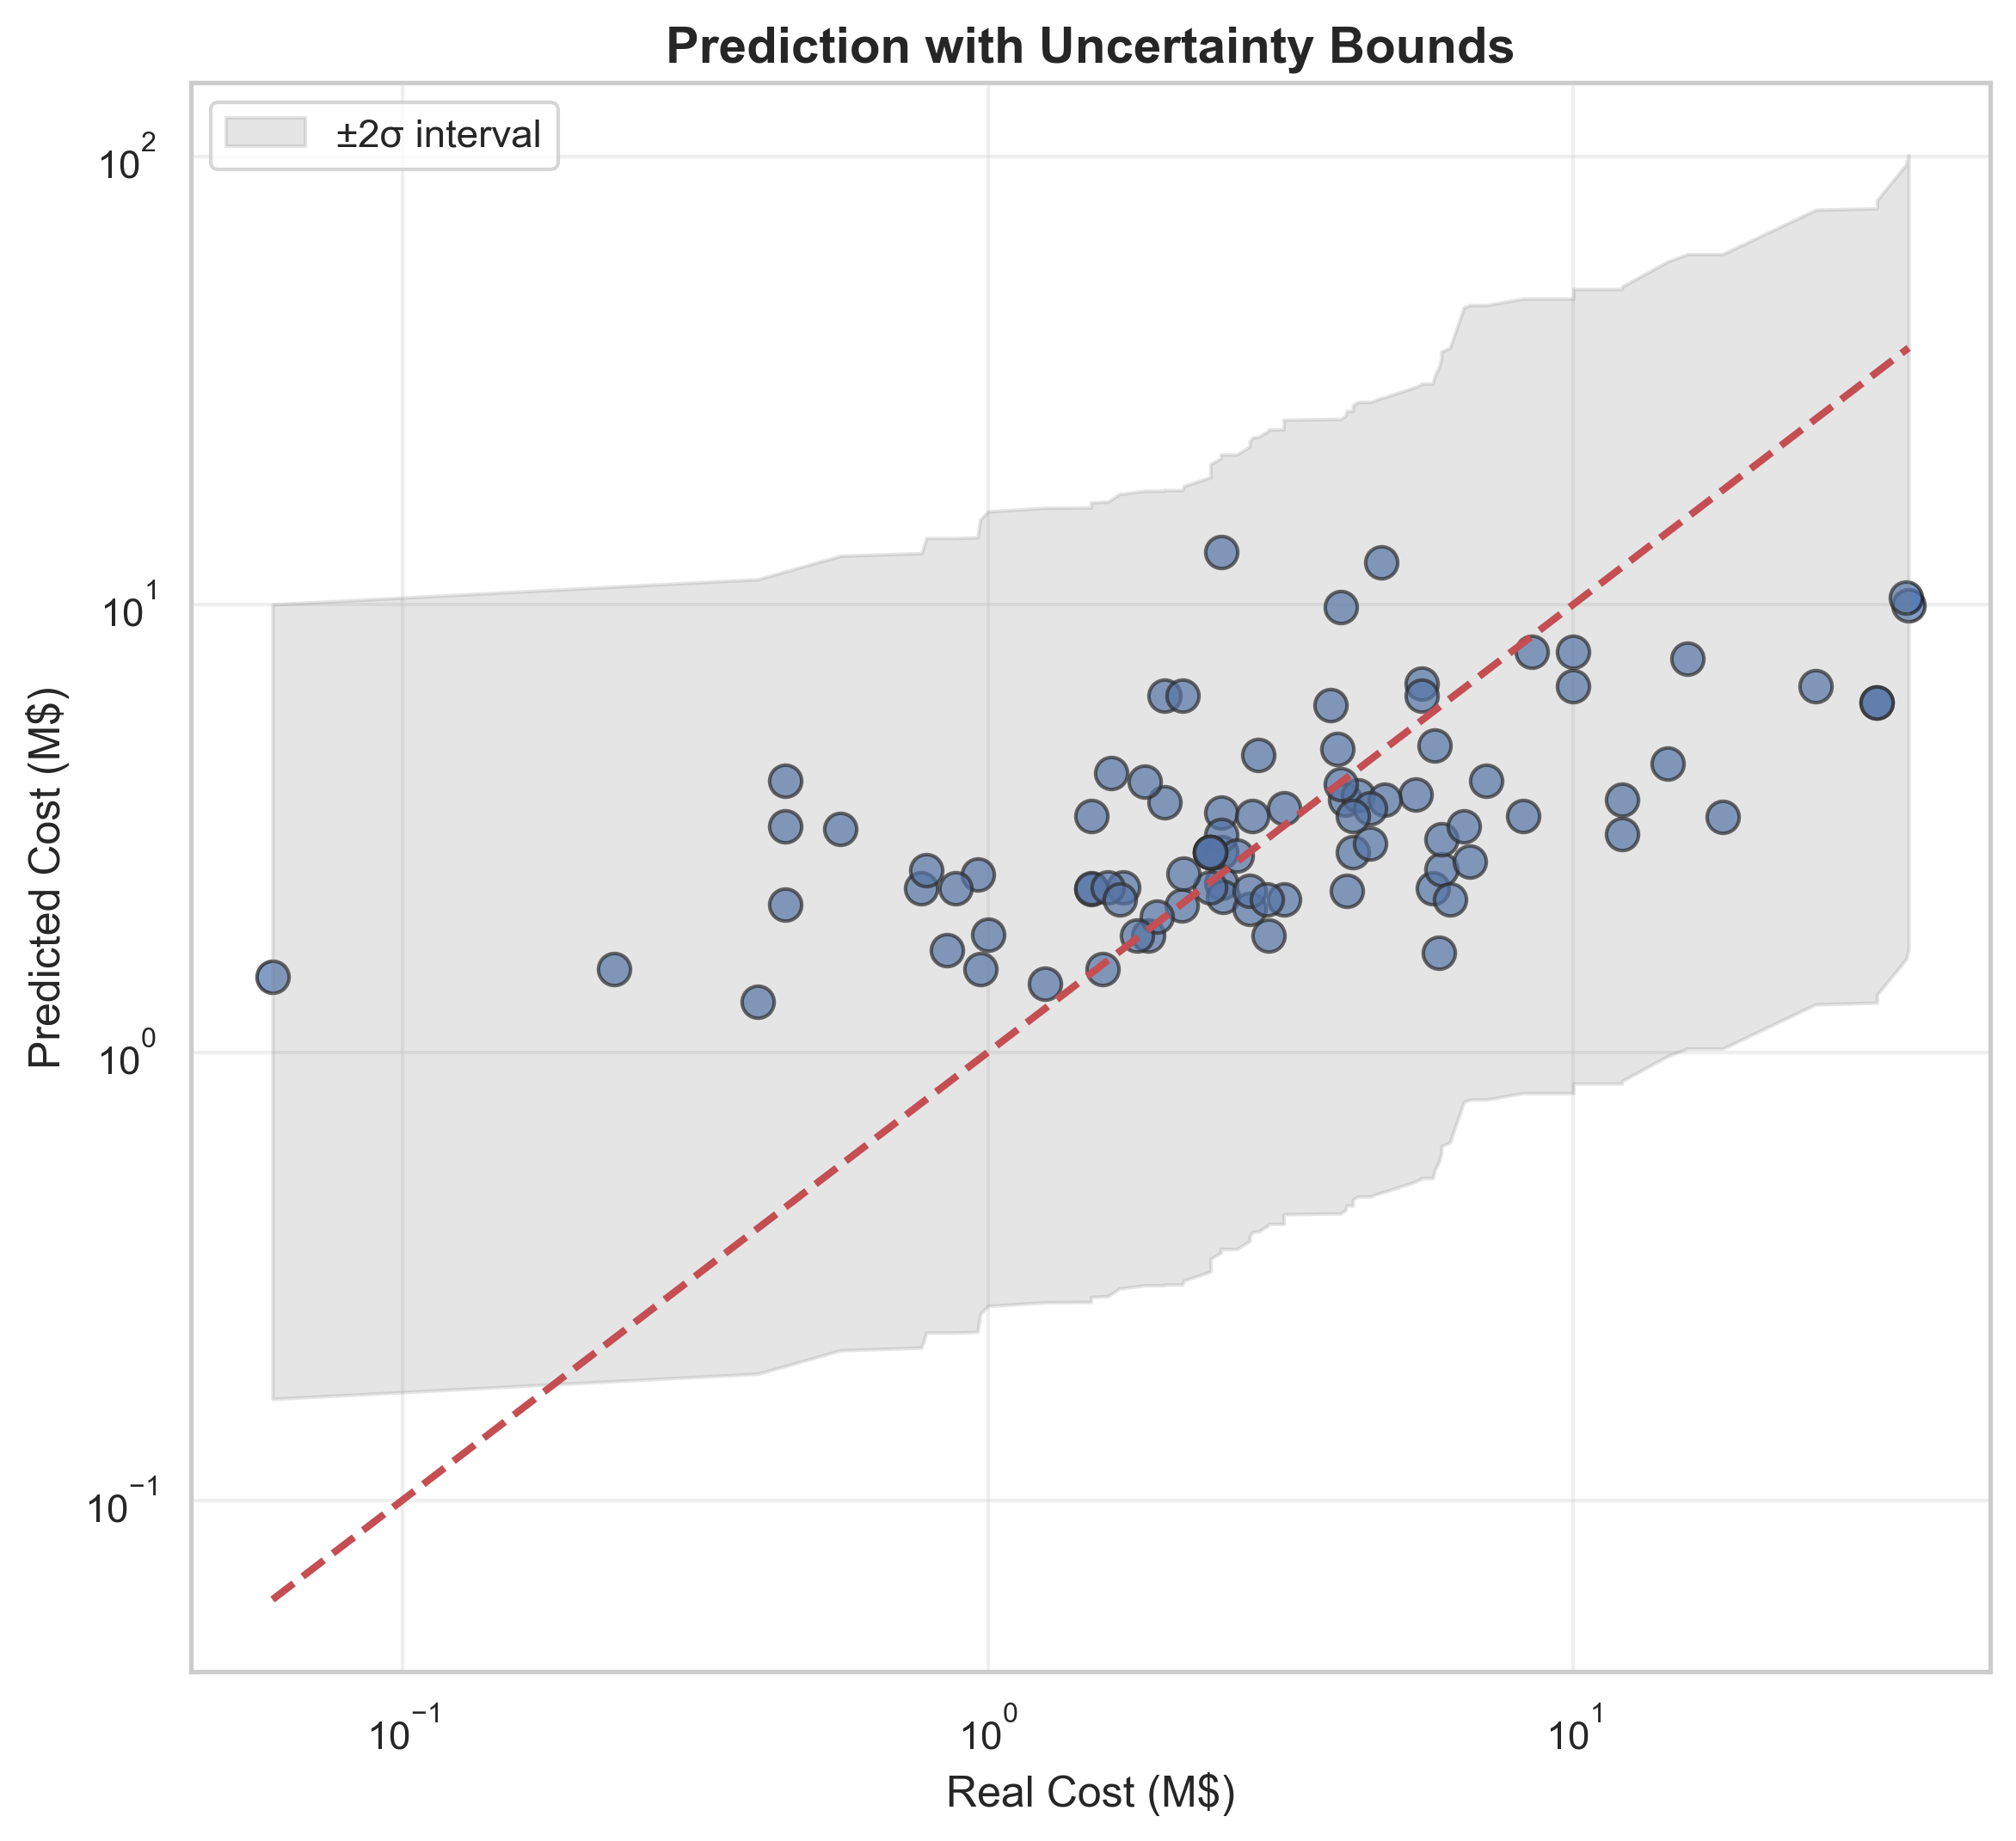

In [27]:
sigma_val = 1.021

lower = np.exp(np.log(y_pred) - 2*sigma_val)
upper = np.exp(np.log(y_pred) + 2*sigma_val)

plt.figure(figsize=(9, 8))

plt.scatter(y_real, y_pred, alpha=0.7, edgecolors='k', s=80)

# zone d'incertitude
plt.fill_between(
    np.sort(y_real),
    np.sort(lower),
    np.sort(upper),
    color='gray',
    alpha=0.2,
    label='±2σ interval'
)

# ligne parfaite
min_val = min(y_real.min(), y_pred.min())
max_val = max(y_real.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2)

plt.xscale('log')
plt.yscale('log')

plt.title("Prediction with Uncertainty Bounds", fontsize=14, fontweight='bold')
plt.xlabel("Real Cost (M$)")
plt.ylabel("Predicted Cost (M$)")

plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
